# OpenClassrooms - parcours Data Analyst Business Intelligence - P8
### **Réalisez une analyse de données en Python**


## Navigation
👉 Ouvrir : **Affichage → Table des matières** (sommaire cliquable généré automatiquement par Colab)

# Configuration et Montage du drive

In [ ]:
# --- Colab / Drive : montage + dossiers projet ---
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')

PROJECT_ROOT = Path('/content/drive/MyDrive/OC_P8_Immobilier') if IN_COLAB else Path('.').resolve()

DIR_RAW   = PROJECT_ROOT / 'data' / '00_raw'
DIR_S1    = PROJECT_ROOT / 'data' / '01_step1_eda'
DIR_S2    = PROJECT_ROOT / 'data' / '02_step2_features'
DIR_S3    = PROJECT_ROOT / 'data' / '03_step3_predictions'
DIR_FIG   = PROJECT_ROOT / 'reports' / 'figures'
DIR_MODEL = PROJECT_ROOT / 'models'

for d in [DIR_RAW, DIR_S1, DIR_S2, DIR_S3, DIR_FIG, DIR_MODEL]:
    d.mkdir(parents=True, exist_ok=True)

# Fichiers attendus (à déposer dans data/00_raw/)
RAW_HISTO_FILE = DIR_RAW / 'historique_immobilier_paris_2017_2021_vdef2.xlsx'

# Portefeuille : on cherche automatiquement le bon fichier
candidats = list(DIR_RAW.glob("portefeuille_actifs*.xlsx"))
RAW_PORTF_FILE = candidats[0] if candidats else (DIR_RAW / 'portefeuille_actifs.xlsx')

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RAW_HISTO_FILE exists ? ->', RAW_HISTO_FILE.exists())
print('RAW_PORTF_FILE exists ? ->', RAW_PORTF_FILE.exists())


Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/OC_P8_Immobilier
RAW_HISTO_FILE exists ? -> True
RAW_PORTF_FILE exists ? -> True


# Milestone 0 - Importation des librairies

In [ ]:
#On importe les librairies que nous utiliserons pour traiter les données et les visualiser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# Milestone 1 - Analyse des données

Dans cette partie nous allons analyser le jeu de données que nous avons à notre disposition. Notre objectif est de comprendre les relations entre les variables, et surtout, celles qui influent sur le prix des transactions immobilières. Grâce à ce travail, nous pourrons ne conserver que les variables qui seront utiles à l'apprentissage de notre algorithme.

## 0.Contrôles qualité préalables

In [ ]:
# Importation des jeux de données
df = pd.read_excel(RAW_HISTO_FILE, parse_dates=['date_mutation'])

print('\nDataframe "historique_immobilier_paris_2017_2021_vdef2.xlsx"')
print('---------------------------------------------------------------')
display(df.head())
print("Shape:", df.shape)

# Taux de valeurs manquantes par colonne
print('\nTaux de valeurs manquantes par colonne')
print('-----------------------------------------')
na_rate = (df.isna().mean()*100).sort_values(ascending=False).round(2)
display(na_rate)

# Doublons exacts (toutes colonnes)
print("\nDoublons exacts :", df.duplicated().sum())

# Contrôle surfaces : <=0 ou nulles (impossible en vrai, sauf logement quantique)
bad_surface = df[(df["surface_reelle"].isna()) | (df["surface_reelle"] <= 0)]
print('---------------------------------------------------------')
print("Lignes avec surface manquante ou <=0 :", len(bad_surface))
print('---------------------------------------------------------')
display(bad_surface.head())


Dataframe "historique_immobilier_paris_2017_2021_vdef2.xlsx"
---------------------------------------------------------------


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15


Shape: (26196, 9)

Taux de valeurs manquantes par colonne
-----------------------------------------


,0
date_mutation,0.0
valeur_fonciere,0.0
adresse_numero,0.0
adresse_nom_voie,0.0
code_postal,0.0
nom_commune,0.0
code_type_local,0.0
type_local,0.0
surface_reelle,0.0



Doublons exacts : 16
---------------------------------------------------------
Lignes avec surface manquante ou <=0 : 0
---------------------------------------------------------


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle


In [ ]:
# Afficher les doublons
doublons = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
print("Nb doublons exacts (lignes) :", len(doublons))
display(doublons)

Nb doublons exacts (lignes) : 32


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle
2768,2017-01-04,885116.628219,8,RUE PAUL HERVIEU,75015,Paris 15e Arrondissement,2,Appartement,98
2775,2017-01-04,885116.628219,8,RUE PAUL HERVIEU,75015,Paris 15e Arrondissement,2,Appartement,98
3435,2017-05-16,108677.313288,7,RUE DOCTEUR GERMAIN SEE,75016,Paris 16e Arrondissement,2,Appartement,11
3436,2017-05-16,108677.313288,7,RUE DOCTEUR GERMAIN SEE,75016,Paris 16e Arrondissement,2,Appartement,11
196,2017-05-18,246703.319425,400,RUE SAINT HONORE,75001,Paris 1er Arrondissement,4,Local industriel. commercial ou assimilé,19
209,2017-05-18,246703.319425,400,RUE SAINT HONORE,75001,Paris 1er Arrondissement,4,Local industriel. commercial ou assimilé,19
375,2017-10-17,855144.863014,71,RUE D AMSTERDAM,75008,Paris 8e Arrondissement,2,Appartement,82
376,2017-10-17,855144.863014,71,RUE D AMSTERDAM,75008,Paris 8e Arrondissement,2,Appartement,82
4755,2017-12-20,132855.435616,18,RUE SIMART,75018,Paris 18e Arrondissement,2,Appartement,15
4756,2017-12-20,132855.435616,18,RUE SIMART,75018,Paris 18e Arrondissement,2,Appartement,15


In [ ]:
# Supprimer les doublons
df_sans_doublons = df.drop_duplicates().reset_index(drop=True).copy()

print("Avant :", df.shape)
print("Après :", df_sans_doublons.shape)
print("Doublons restants :", df_sans_doublons.duplicated().sum())

df = df_sans_doublons

Avant : (26196, 9)
Après : (26180, 9)
Doublons restants : 0


## 1.Type des données

In [ ]:
#On vérifie que le type des données attribué par pandas est cohérent
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26180 entries, 0 to 26179
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26180 non-null  datetime64[ns]
 1   valeur_fonciere   26180 non-null  float64       
 2   adresse_numero    26180 non-null  int64         
 3   adresse_nom_voie  26180 non-null  object        
 4   code_postal       26180 non-null  int64         
 5   nom_commune       26180 non-null  object        
 6   code_type_local   26180 non-null  int64         
 7   type_local        26180 non-null  object        
 8   surface_reelle    26180 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 1.8+ MB


In [ ]:
# Analyse des types de variables
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
date_cols = df.select_dtypes(include=["datetime64[ns]"]).columns.tolist()

print("Numériques :", num_cols)
print("Catégorielles :", cat_cols)
print("Temporelles :", date_cols)

Numériques : ['valeur_fonciere', 'adresse_numero', 'code_postal', 'code_type_local', 'surface_reelle']
Catégorielles : ['adresse_nom_voie', 'nom_commune', 'type_local']
Temporelles : ['date_mutation']


**Variable temporelle** : *date_mutation (datetime)* → permet de mesurer l’évolution des prix et de capter l’effet “cycle de marché”.

**Variables quantitatives** :

*   valeur_fonciere (montant) → utile mais dépend fortement de la surface, donc on privilégie un indicateur normalisé prix au m².
*   surface_reelle (m²) → variable explicative structurante (la valeur augmente avec la surface).



**Variables qualitatives (catégorielles)** :

*   code_postal / nom_commune → localisation (arrondissement) ; pouvoir explicatif fort sur les niveaux de prix.
*   code_type_local / type_local → segmentation (appartement vs local commercial) ; important pour comparer des marchés différents.



**Variables de type “adresse”** : adresse_numero, adresse_nom_voie → informations très granularisées, souvent bruyantes et peu pertinentes en première analyse agrégée ; elles deviennent éventuellement utiles si on faisait du modèle très fin “à l’adresse”, ce qui n’est pas l’objectif ici.

## 2.Regardons les différents types de biens immobiliers que nous avons dans nos données :

In [ ]:
print('La liste des différents types de biens immobiliers que nous avons dans les données est:')
types_biens = (df[['code_type_local','type_local']]
               .drop_duplicates()
               .sort_values('code_type_local')
               .reset_index(drop=True))
display(types_biens)

# Commentaire
codes = types_biens["code_type_local"].tolist()
libelles = types_biens["type_local"].tolist()

commentaire = (
    f"On observe {len(types_biens)} types de biens immobiliers dans les données avec les types suivants : "
    + ", ".join([f"{c} = {l}" for c, l in zip(codes, libelles)])
    + "."
)

print(commentaire)

La liste des différents types de biens immobiliers que nous avons dans les données est:


,code_type_local,type_local
0,2,Appartement
1,4,Local industriel. commercial ou assimilé


On observe 2 types de biens immobiliers dans les données avec les types suivants : 2 = Appartement, 4 = Local industriel. commercial ou assimilé.


### 3.Nombre de transactions

In [ ]:
#On verifie le nombre de transactions que nous avons dans notre dataframe
nb_total = len(df)
nb_app = (df['type_local'] == 'Appartement').sum()
nb_loc = (df['type_local'] != 'Appartement').sum()

print("Le nombre de transactions dans les données est :", nb_total)
print("Le nombre de transactions pour les appartements dans les données est :", nb_app)
print("Le nombre de transactions pour les locaux commerciaux dans les données est :", nb_loc)

Le nombre de transactions dans les données est : 26180
Le nombre de transactions pour les appartements dans les données est : 24338
Le nombre de transactions pour les locaux commerciaux dans les données est : 1842


### 4.Interval de l'historique des données

In [ ]:
#On vérifie également la plage de l'historique disponible
print("La première date de transaction dans les données est le :", df['date_mutation'].min().date())
print("la dernière date de transaction dans les données est le :", df['date_mutation'].max().date())

La première date de transaction dans les données est le : 2017-01-02
la dernière date de transaction dans les données est le : 2021-12-31


## Commençons à analyser les données

Maintenant nous allons analyser les données historiques pour les 2 différents types de biens immobiliers en essayant d'identifier les relations entre les variables. Mais avant cela, il nous faudra pouvoir comparer les biens entre eux, et pour cela nous allons créer une colonne du prix au metre carré.

In [ ]:
# Calcul de la colonne "Prix au mètre carré"
# -- On crée prix_m2 + variables temporelles, puis on agrège par année
df = df.copy()
df['prix_m2'] = df['valeur_fonciere'] / df['surface_reelle']
df['annee'] = df['date_mutation'].dt.year
df['mois']  = df['date_mutation'].dt.to_period('M').dt.to_timestamp()
df.head()

,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2,annee,mois
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50,11011.193562,2017,2017-01-01
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163,9671.732877,2017,2017-01-01
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66,9966.020548,2017,2017-01-01
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22,11367.582877,2017,2017-01-01
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15,11751.113836,2017,2017-01-01


Maintenant, analysons les appartements.

### 5.Evolution du prix au metre carré des appartements dans Paris

In [ ]:
#On retire les colonnes qui sont à priori inutiles ET nous allons nous concentrer sur les appartements dans un premier temps

# Colonnes utiles à l'analyse Step 1
# Nous réduisons le jeu de données aux variables utiles à l’analyse des prix (temps, surface, type de bien, localisation, prix/m²) afin de simplifier la manipulation et la lecture
cols_keep = [
    "date_mutation",
    "valeur_fonciere",
    "surface_reelle",
    "code_postal",
    "nom_commune",
    "code_type_local",
    "type_local",
    "prix_m2",
    "annee",
    "mois"
]

df_analyse = df[cols_keep].copy()

# Se concentrer sur les appartements
# Nous isolons ensuite les transactions portant sur des appartements pour étudier la tendance du marché résidentiel avant de comparer avec les locaux commerciaux.
df_app = df_analyse[df_analyse["type_local"] == "Appartement"].copy()
print("Transactions appart :", len(df_app))
display(df_app.head())


Transactions appart : 24338


,date_mutation,valeur_fonciere,surface_reelle,code_postal,nom_commune,code_type_local,type_local,prix_m2,annee,mois
0,2017-01-03,5.505597e+05,50,75003,Paris 3e Arrondissement,2,Appartement,11011.193562,2017,2017-01-01
1,2017-01-12,1.576492e+06,163,75008,Paris 8e Arrondissement,2,Appartement,9671.732877,2017,2017-01-01
2,2017-01-10,6.577574e+05,66,75008,Paris 8e Arrondissement,2,Appartement,9966.020548,2017,2017-01-01
3,2017-01-10,2.500868e+05,22,75003,Paris 3e Arrondissement,2,Appartement,11367.582877,2017,2017-01-01
4,2017-01-13,1.762667e+05,15,75001,Paris 1er Arrondissement,2,Appartement,11751.113836,2017,2017-01-01


In [ ]:
#Préparons un dataframe en regroupant les prix moyens de ventes des appartements par année avec la surface moyenne associée
df_app_year = (df_app.groupby("annee")
               .agg(prix_m2_moyen=("prix_m2", "mean"),
                    surface_moyenne=("surface_reelle", "mean"),
                    nb_transactions=("prix_m2", "size"))
               .reset_index())

df_app_year["prix_m2_moyen"] = df_app_year["prix_m2_moyen"].round(0)
df_app_year["surface_moyenne"] = df_app_year["surface_moyenne"].round(1)

display(df_app_year)

,annee,prix_m2_moyen,surface_moyenne,nb_transactions
0,2017,9492.0,44.6,5201
1,2018,10031.0,44.3,5076
2,2019,10562.0,43.4,5245
3,2020,10675.0,42.9,4123
4,2021,10456.0,43.5,4693


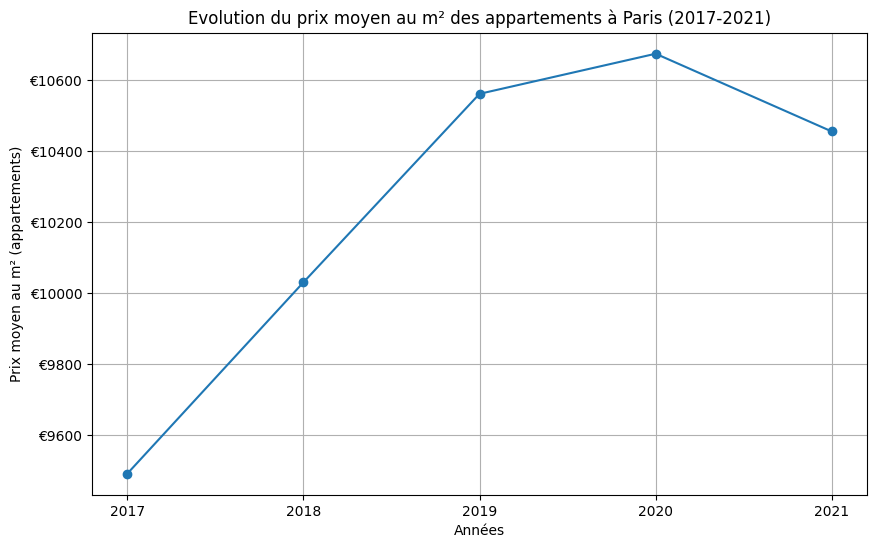

In [ ]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix
plt.figure(figsize=(10,6))
plt.plot(df_app_year['annee'].astype(str), df_app_year['prix_m2_moyen'], marker='o')
plt.xlabel("Années")
plt.ylabel("Prix moyen au m² (appartements)")
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter("€%d"))
plt.grid(True)
plt.title("Evolution du prix moyen au m² des appartements à Paris (2017-2021)")
plt.show()

**Hausse 2017→2020, léger reflux en 2021, avec un ordre de grandeur ≈ +10% sur 2017→2021.**

### 6.Différences de prix au metre carré entre les arrondissements

Maintenant nous allons chercher à afficher l'évolution des prix par arrondissement. Vérifions la liste des arrondissements que nous avons dans nos données. Normalement à Paris nous avons 20 codes postaux différents, 1 par arrondissement allant de 75001 à 75020.

In [ ]:
#Liste des codes postaux dans nos données. _ Mapping code_postal -> nom_commune
cp_commune = (df[["code_postal","nom_commune"]]
              .drop_duplicates()
              .sort_values("code_postal")
              .reset_index(drop=True))
display(cp_commune)

,code_postal,nom_commune
0,75001,Paris 1er Arrondissement
1,75002,Paris 2e Arrondissement
2,75003,Paris 3e Arrondissement
3,75004,Paris 4e Arrondissement
4,75005,Paris 5e Arrondissement
5,75006,Paris 6e Arrondissement
6,75007,Paris 7e Arrondissement
7,75008,Paris 8e Arrondissement
8,75009,Paris 9e Arrondissement
9,75010,Paris 10e Arrondissement


In [ ]:
#Créeons un dataframe pour une deuxième visualisation avec l'evolution des prix par arrondissement
df_arr_year = (df_app.groupby(['code_postal','annee'])
               .agg(prix_m2_moyen=('prix_m2','mean'))
               .reset_index())
df_arr_year['prix_m2_moyen'] = df_arr_year['prix_m2_moyen'].round(0)

pivot = (df_arr_year.pivot(index='annee', columns='code_postal', values='prix_m2_moyen')
         .sort_index())
display(df_arr_year)

,code_postal,annee,prix_m2_moyen
0,75001,2017,11763.0
1,75001,2018,12621.0
2,75001,2019,13269.0
3,75001,2020,13406.0
4,75001,2021,13379.0
...,...,...,...
95,75020,2017,7886.0
96,75020,2018,8485.0
97,75020,2019,9094.0
98,75020,2020,9329.0


**Visualisation de la hausse des prix au mètre carré dans le premier arrondissement**

,code_postal,annee,prix_m2_moyen
0,75001,2017,11763.0
1,75001,2018,12621.0
2,75001,2019,13269.0
3,75001,2020,13406.0
4,75001,2021,13379.0


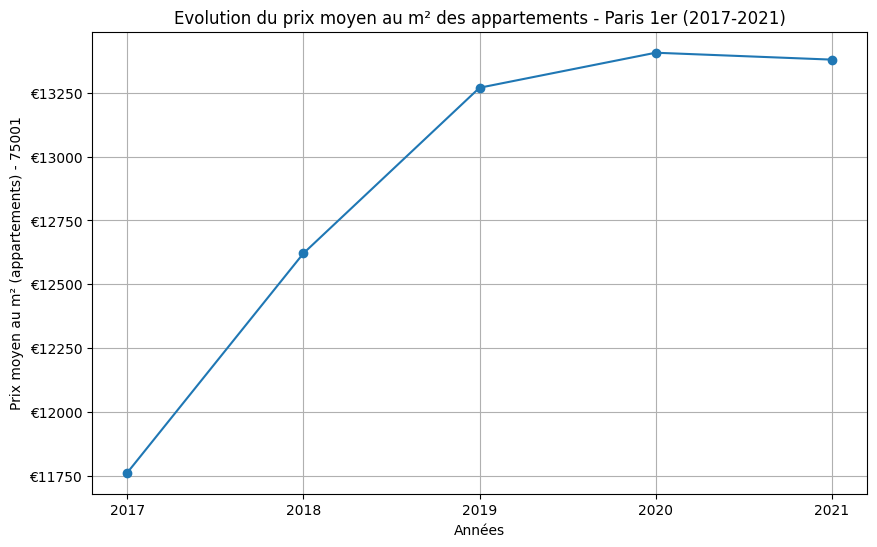

In [ ]:
#Création d'un graphique pour visualiser la hausse de la moyenne des prix au metre carré dans le premier arrondissement

# Filtrer l'arrondissement (75001)
df_75001_year = df_arr_year[df_arr_year["code_postal"] == 75001].copy()

# Sécuriser l'ordre chronologique
df_75001_year = df_75001_year.sort_values("annee")

display(df_75001_year)

# Graphique
plt.figure(figsize=(10,6))
plt.plot(df_75001_year["annee"].astype(str), df_75001_year["prix_m2_moyen"], marker="o")
plt.xlabel("Années")
plt.ylabel("Prix moyen au m² (appartements) - 75001")
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter("€%d"))
plt.grid(True)
plt.title("Evolution du prix moyen au m² des appartements - Paris 1er (2017-2021)")
plt.show()

Nous allons ajouter à cette visualisation tous les autres arrondissement avec une couleur différente.

**Visusalisation du prix au mètre carré dans tous les arrondissements**

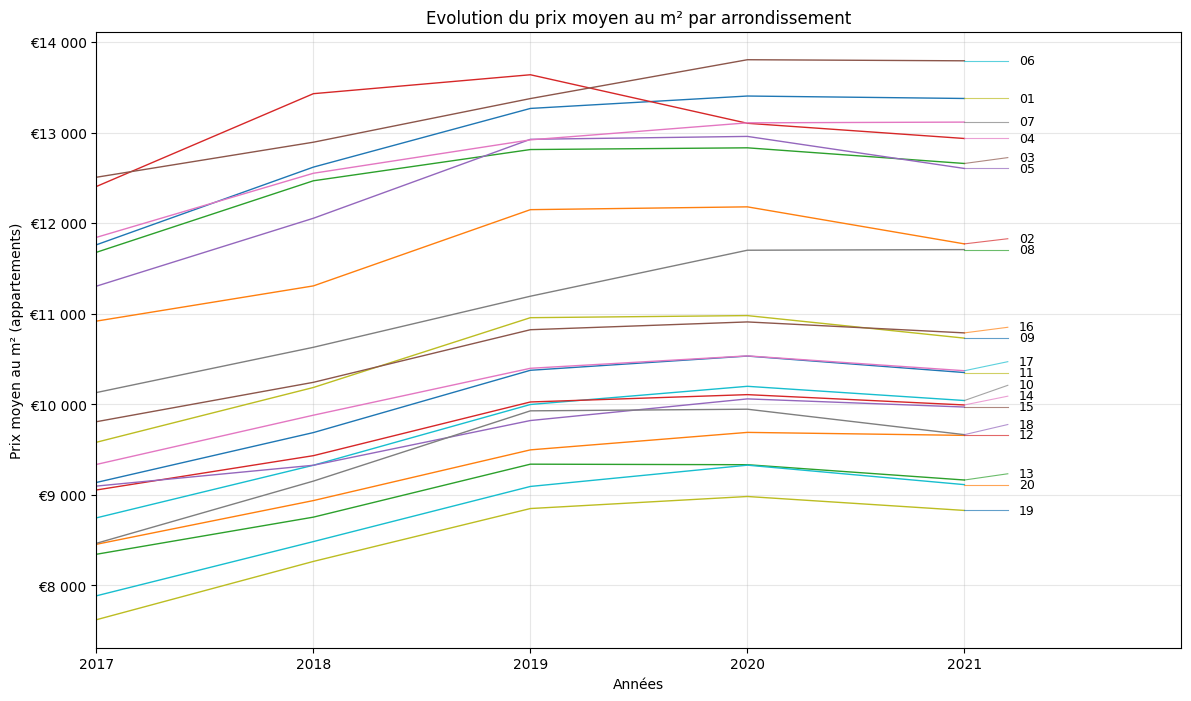

In [ ]:
#On affiche l'évolution du prix au m² par arrondissement dans Paris

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --- Paramètres ---
gap_euros = 120          # écart vertical minimum entre labels (à ajuster : 80, 120, 150...)
x_pad = 1.0              # espace à droite pour les labels (en "années")
alpha_lines = 1
line_width = 2

years = pivot.index.astype(int).to_numpy()
x_last = years.max()
x_text = x_last + 0.25   # position des labels (à droite)

# Valeurs en dernière année (fin de courbe)
last_vals = pivot.loc[x_last].dropna()

# Tri par niveau de prix (du bas vers le haut)
order = last_vals.sort_values().index.tolist()
y = last_vals.loc[order].to_numpy()

# --- Algorithme de décalage des labels (stagger) ---
ymin, ymax = np.nanmin(y), np.nanmax(y)
y_adj = y.copy()

# Passe avant : impose un gap minimal
for i in range(1, len(y_adj)):
    y_adj[i] = max(y_adj[i], y_adj[i-1] + gap_euros)

# Si on dépasse ymax, on redescend tout le bloc
overflow = y_adj[-1] - ymax
if overflow > 0:
    y_adj = y_adj - overflow

# Passe arrière : évite de casser le gap en bas
for i in range(len(y_adj)-2, -1, -1):
    y_adj[i] = min(y_adj[i], y_adj[i+1] - gap_euros)

# Si on passe sous ymin, on remonte tout le bloc
underflow = ymin - y_adj[0]
if underflow > 0:
    y_adj = y_adj + underflow

# --- Plot ---
plt.figure(figsize=(14,8))

# Courbes
for cp in pivot.columns:
    plt.plot(years, pivot[cp].values, alpha=alpha_lines, linewidth=1)

# Labels décalés + traits de liaison
for cp, y_last_real, y_lab in zip(order, y, y_adj):
    arr = int(str(int(cp))[-2:])  # 75001 -> 1 ... 75020 -> 20

    # Trait de liaison (fin de courbe -> label)
    plt.plot([x_last, x_text-0.05], [y_last_real, y_lab], linewidth=0.8, alpha=0.7)
    # Label
    plt.text(x_text, y_lab, f"{arr:02d}", va="center", fontsize=9)

# Axe Y en euros lisibles
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"€{int(v):,}".replace(",", " ")))

plt.xticks(years)
plt.xlim(years.min(), x_last + x_pad)
plt.xlabel("Années")
plt.ylabel("Prix moyen au m² (appartements)")
plt.grid(True, alpha=0.3)
plt.title("Evolution du prix moyen au m² par arrondissement")
plt.show()

**On observe globalement que :**
*   Les arrondissements suivent globalement la même tendance temporelle (hausse sur la période), mais avec des niveaux de prix structurellement différents selon la localisation.
*   Les écarts entre arrondissements restent marqués, traduisant une segmentation géographique forte du marché parisien.

**Lecture métier :** tous les arrondissements suivent la tendance macro, mais avec des niveaux structurellement différents (centre vs périphérie).
Top : 75006/75001/75007/75004 _  Down : 75019/75020/75013/75012.

**Prix au metre carré par transaction dans un arrondissement (le 6 ème)**

Transactions appartements 75006 : 709


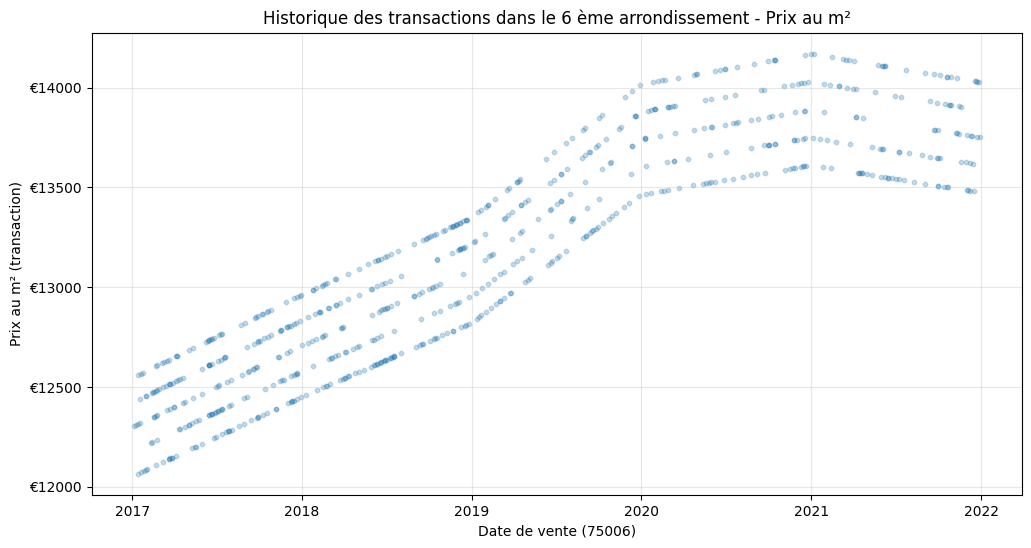

In [ ]:
#Vérifions le nombre de transaction dans le 6ème car le prix semble élevé
cp = 75006
df_app_6 = df_app[df_app['code_postal']==cp].copy()
print("Transactions appartements 75006 :", len(df_app_6))

plt.figure(figsize=(12,6))
plt.scatter(df_app_6['date_mutation'], df_app_6['prix_m2'], s=10, alpha=0.25)
plt.xlabel("Date de vente (75006)")
plt.ylabel("Prix au m² (transaction)")
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter("€%d"))
plt.grid(True, alpha=0.3)
plt.title("Historique des transactions dans le 6 ème arrondissement - Prix au m²")
plt.show()


**Ce qu’on constate ?**

Le prix au m² des appartements du 6 ème arrondissement augmente globalement sur la période 2017–2021. Le nuage de points met en évidence une tendance haussière marquée jusqu’en 2020, puis une stabilisation relative en fin de période. La dispersion des points reflète l’hétérogénéité des biens mais la dynamique temporelle reste clairement identifiable.

**Pourquoi afficher l’historique (dispersion) ?**

Pour visualiser la variabilité des prix au m² à l’intérieur d’un même arrondissement.

Pour vérifier qu’il n’y a pas de comportement “aléatoire” : ici, on voit au contraire une structure temporelle (donc une relation plausible entre date et prix).

**Nous rassurer avec un test staistique**

Afin d’objectiver cette relation visuelle entre la date de transaction et le prix au m², nous réalisons un test de corrélation (Pearson) : il permet de quantifier la force et le sens du lien et de confirmer statistiquement la tendance observée.



### 7.Vérification de la relation entre le prix au m² et la date dans le 6ème arrondissement par le calcul du coefficient de corrélation de Pearson

Pour cette distribution nous allons calculer le coefficient de corrélation de Pearson. La relation entre le prix au metre carré et la date n'est pas forcément linéaire mais elle s'en rapproche suffisamment pour que cette analyse soit pertinente (voir l'évolution du prix au metre carré globale montrée plus haut, on a presque une droite sauf entre 2020 et 2021). Ce qui nous interesse c'est de prouver que le temps a une influence sur le prix.

In [ ]:
# On calcule la corrélation de Pearson et de Spearman
from scipy import stats

x = df_app_6['date_mutation'].map(pd.Timestamp.toordinal)
y = df_app_6['prix_m2']

pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_r, spearman_p = stats.spearmanr(x, y)

print(f"Pearson r = {pearson_r:.3f} | p-value = {pearson_p:.3e}")
print(f"Spearman rho = {spearman_r:.3f} | p-value = {spearman_p:.3e}")



Pearson r = 0.904 | p-value = 7.108e-263
Spearman rho = 0.915 | p-value = 1.200e-280


Les deux tests indiquent une **corrélation très forte et positive** entre la date de transaction et le prix au m² dans le 6e arrondissement : r(Pearson)=0,904 et ρ(Spearman)=0,915. **Les p-values sont extrêmement faibles (≪ 0,05)**, ce qui signifie que la **corrélation observée est statistiquement significative**.
On confirme donc l’existence d’une tendance haussière marquée du prix au m² sur la période étudiée. Le fait que Spearman soit légèrement supérieur à Pearson suggère une relation très monotone, potentiellement avec de légères non-linéarités mais une dynamique globale clairement croissante.

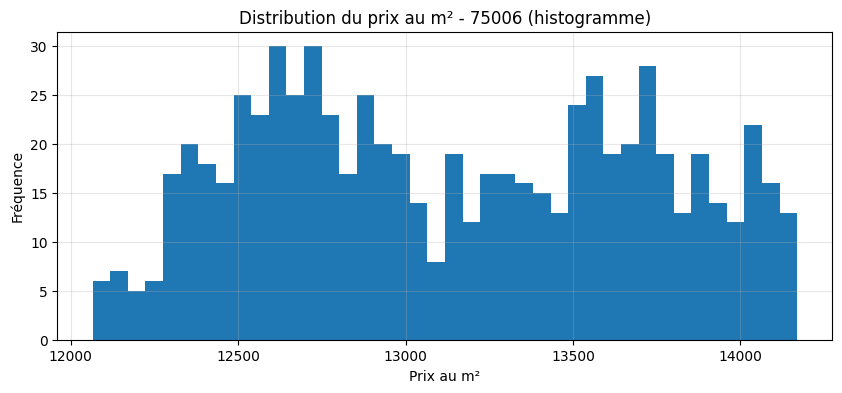

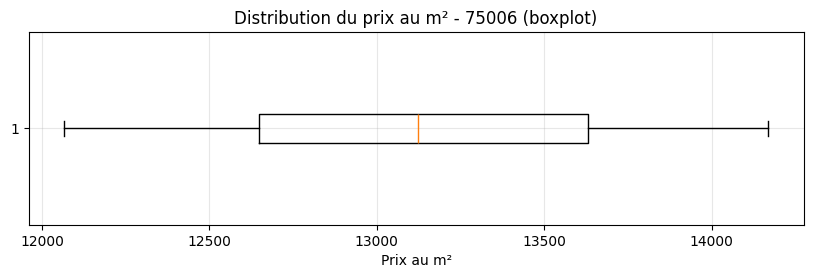

In [ ]:
# Vérification de la nature de la distribution justifiant Spearman
import matplotlib.pyplot as plt

# Histogramme
plt.figure(figsize=(10,4))
plt.hist(df_app_6["prix_m2"], bins=40)
plt.title("Distribution du prix au m² - 75006 (histogramme)")
plt.xlabel("Prix au m²"); plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.show()

# Boxplot
plt.figure(figsize=(10,2.5))
plt.boxplot(df_app_6["prix_m2"], vert=False)
plt.title("Distribution du prix au m² - 75006 (boxplot)")
plt.xlabel("Prix au m²")
plt.grid(True, alpha=0.3)
plt.show()

La distribution du prix au m² n’est pas parfaitement normale (forme irrégulière / hétérogène). **Spearman, basé sur les rangs, est donc plus robuste que Pearson aux non-normalités et aux valeurs atypiques** ; la convergence des deux résultats confirme une tendance haussière solide.

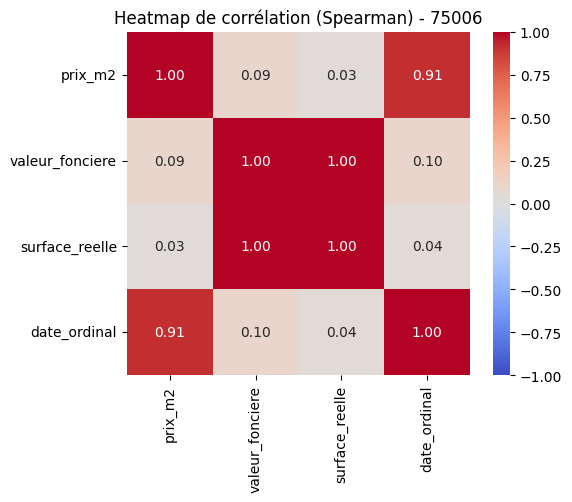

In [ ]:
# Heatmap Spearman
df_corr = df_app_6.copy()
df_corr["date_ordinal"] = df_corr["date_mutation"].map(pd.Timestamp.toordinal)

cols = ["prix_m2", "valeur_fonciere", "surface_reelle", "date_ordinal"]
corr_s = df_corr[cols].corr(method="spearman")

plt.figure(figsize=(6,5))
sns.heatmap(corr_s, annot=True, fmt=".2f", square=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Heatmap de corrélation (Spearman) - 75006")
plt.tight_layout()
plt.show()

### 8.Vérification de la relation entre la valeur foncière et la surface

In [ ]:
# Pearson (linéaire)
r_val_surf, p_val_surf = stats.pearsonr(df_app["valeur_fonciere"], df_app["surface_reelle"])

# Spearman (monotone, robuste)
rho_val_surf, p_rho_val_surf = stats.spearmanr(df_app["valeur_fonciere"], df_app["surface_reelle"])

print(f"Pearson  (valeur vs surface)  : r   = {r_val_surf:.3f} | p-value = {p_val_surf:.3e}")
print(f"Spearman (valeur vs surface)  : rho = {rho_val_surf:.3f} | p-value = {p_rho_val_surf:.3e}")

Pearson  (valeur vs surface)  : r   = 0.980 | p-value = 0.000e+00
Spearman (valeur vs surface)  : rho = 0.977 | p-value = 0.000e+00


**Résultat corrélations (valeur foncière vs surface – appartements)**
Le coefficient de corrélation de Pearson est de r = 0,980 avec une p-value ≈ 0,000e+00 (donc très largement < 0,05).
Le coefficient de corrélation de Spearman est de ρ = 0,977 avec une p-value ≈ 0,000e+00.
**Ces résultats montrent une relation très forte, positive et statistiquement significative :** plus la surface est grande, plus la valeur foncière augmente. La convergence Pearson/Spearman indique que la relation est à la fois quasi linéaire et monotone, et robuste aux éventuelles valeurs atypiques.

Regardons maintenant si le type de bien à une influence sur le prix au metre carré également.

### 9.Analyse des locaux industriels, commerciaux et assimilés

In [ ]:
#Préparons un dataframe en regroupant les prix au metre carré moyens des ventes par année


,annee,prix_m2_app,prix_m2_loc
0,2017,9492.0,10944.0
1,2018,10031.0,11569.0
2,2019,10562.0,11960.0
3,2020,10675.0,11966.0
4,2021,10456.0,12006.0


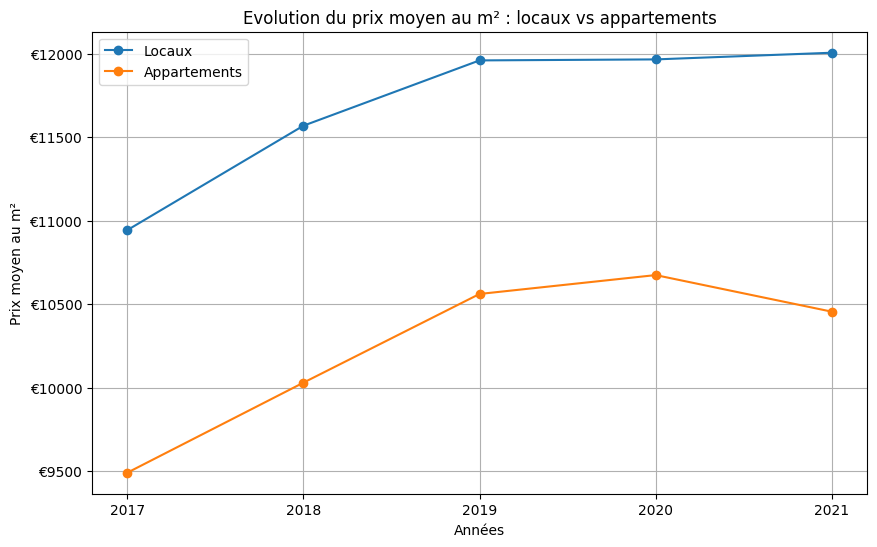

In [ ]:
# -----------------------------------------------
# Appartements vs locaux commerciaux
# ------------------------------------------
df_loc = df[df['type_local']!='Appartement'].copy()

df_loc_year = (df_loc.groupby('annee')
               .agg(prix_m2_moyen=('prix_m2','mean'),
                    nb_transactions=('prix_m2','size'))
               .reset_index())
df_loc_year['prix_m2_moyen'] = df_loc_year['prix_m2_moyen'].round(0)

df_comp = (df_app_year[['annee','prix_m2_moyen']].rename(columns={'prix_m2_moyen':'prix_m2_app'})
           .merge(df_loc_year[['annee','prix_m2_moyen']].rename(columns={'prix_m2_moyen':'prix_m2_loc'}),
                  on='annee', how='inner'))
display(df_comp)

plt.figure(figsize=(10,6))
plt.plot(df_comp['annee'].astype(str), df_comp['prix_m2_loc'], label='Locaux', marker='o')
plt.plot(df_comp['annee'].astype(str), df_comp['prix_m2_app'], label='Appartements', marker='o')
plt.xlabel("Années"); plt.ylabel("Prix moyen au m²")
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter("€%d"))
plt.grid(True); plt.legend()
plt.title("Evolution du prix moyen au m² : locaux vs appartements")
plt.show()

Sur la période 2017–2021, **le prix moyen au m² des locaux commerciaux/assimilés est systématiquement supérieur à celui des appartements.** Il passe d’environ 10 950 €/m² en 2017 à 12 006 €/m² en 2021, soit une hausse globale d’environ +9,6%. À titre de comparaison, les appartements progressent fortement jusqu’en 2020, puis connaissent un reflux en 2021 (de 10 675 €/m² à 10 456 €/m²). **L’écart entre les deux segments se creuse au fil du temps (environ +1 457 €/m² en 2021)**, ce qui confirme que **le type de bien (appartement vs local) est une dimension structurante pour l’analyse** et devra être prise en compte dans la suite (modélisation/prédiction).

Après ces analyses, nous pouvons conclure que les dimensions à utiliser pour prédire le prix au m² sont :
- la surface du bien immobilier,
- la date considérée,
- la localisation (code_postal),
- le type de bien.

In [ ]:
# --- Sauvegardes Milestone 1 ---
path_df = DIR_S1 / "transactions_enrichies_step1.parquet"
try:
    df.to_parquet(path_df, index=False)
    print("Dataset sauvegardé ->", path_df)
except Exception as e:
    path_csv = DIR_S1 / "transactions_enrichies_step1.csv"
    df.to_csv(path_csv, index=False)
    print("Parquet indisponible, sauvegarde CSV ->", path_csv)
    print("Détail erreur parquet:", e)

df_app_year.to_csv(DIR_S1 / "app_prixm2_par_annee.csv", index=False)
df_arr_year.to_csv(DIR_S1 / "app_prixm2_par_annee_arrondissement.csv", index=False)
df_comp.to_csv(DIR_S1 / "comparatif_prixm2_locaux_vs_app.csv", index=False)

print("Exports Milestone 1 ->", DIR_S1)

Dataset sauvegardé -> /content/drive/MyDrive/OC_P8_Immobilier/data/01_step1_eda/transactions_enrichies_step1.parquet
Exports Milestone 1 -> /content/drive/MyDrive/OC_P8_Immobilier/data/01_step1_eda


In [ ]:
print('df_app_year')
display(df_app_year.head(10))

print('\ndf_arr_year')
display(df_arr_year.head(10))

print('\ndf_comp')
display(df_comp.head(10))

df_app_year


,annee,prix_m2_moyen,surface_moyenne,nb_transactions
0,2017,9492.0,44.6,5201
1,2018,10031.0,44.3,5076
2,2019,10562.0,43.4,5245
3,2020,10675.0,42.9,4123
4,2021,10456.0,43.5,4693



df_arr_year


,code_postal,annee,prix_m2_moyen
0,75001,2017,11763.0
1,75001,2018,12621.0
2,75001,2019,13269.0
3,75001,2020,13406.0
4,75001,2021,13379.0
5,75002,2017,10920.0
6,75002,2018,11309.0
7,75002,2019,12151.0
8,75002,2020,12182.0
9,75002,2021,11773.0



df_comp


,annee,prix_m2_app,prix_m2_loc
0,2017,9492.0,10944.0
1,2018,10031.0,11569.0
2,2019,10562.0,11960.0
3,2020,10675.0,11966.0
4,2021,10456.0,12006.0


# Milestone 2 - Entraînement de l'algorithme

## Milestone 2.1 - Entraînement de l'algorithme avec sklearn

Dans cette section nous allons maintenant entrâiner un algorithme à prédire la valeur fonciere d'un bien immobilier. Pour cela nous allons utiliser l'algorithme de régression linéaire.

In [ ]:
# Rechargement Dataframe fin Etape 1
import pandas as pd
from pathlib import Path

# Chemin issu de ton export Étape 1
path_df = Path("/content/drive/MyDrive/OC_P8_Immobilier/data/01_step1_eda/transactions_enrichies_step1.parquet")

df_step1 = pd.read_parquet(path_df)

print("Chargement OK :", df_step1.shape)
display(df_step1.head())
df_step1.info()

Chargement OK : (26180, 12)


,date_mutation,valeur_fonciere,adresse_numero,adresse_nom_voie,code_postal,nom_commune,code_type_local,type_local,surface_reelle,prix_m2,annee,mois
0,2017-01-03,5.505597e+05,8,RUE DES COUTURES SAINT GERVAIS,75003,Paris 3e Arrondissement,2,Appartement,50,11011.193562,2017,2017-01-01
1,2017-01-12,1.576492e+06,32,AV MARCEAU,75008,Paris 8e Arrondissement,2,Appartement,163,9671.732877,2017,2017-01-01
2,2017-01-10,6.577574e+05,52,RUE DU FAUBOURG SAINT HONORE,75008,Paris 8e Arrondissement,2,Appartement,66,9966.020548,2017,2017-01-01
3,2017-01-10,2.500868e+05,64,RUE DU VERTBOIS,75003,Paris 3e Arrondissement,2,Appartement,22,11367.582877,2017,2017-01-01
4,2017-01-13,1.762667e+05,25,RUE DES LAVANDIERES STE OPPORT,75001,Paris 1er Arrondissement,2,Appartement,15,11751.113836,2017,2017-01-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26180 entries, 0 to 26179
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mutation     26180 non-null  datetime64[ns]
 1   valeur_fonciere   26180 non-null  float64       
 2   adresse_numero    26180 non-null  int64         
 3   adresse_nom_voie  26180 non-null  object        
 4   code_postal       26180 non-null  int64         
 5   nom_commune       26180 non-null  object        
 6   code_type_local   26180 non-null  int64         
 7   type_local        26180 non-null  object        
 8   surface_reelle    26180 non-null  int64         
 9   prix_m2           26180 non-null  float64       
 10  annee             26180 non-null  int32         
 11  mois              26180 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int32(1), int64(4), object(3)
memory usage: 2.3+ MB


On commence par préparer nos données en transformant les colonnes catégoriques du code postal et du type de local grâce au one hot encoder (sklearn) / get_dummies (pandas)

In [ ]:
# Encodage "code postal" et "type de local" avec One Hot Encoder

# 1) On part de df_step1 (parquet fin étape 1)
df_ml = df_step1[["date_mutation", "valeur_fonciere", "surface_reelle", "code_postal", "type_local"]].copy()

# 2) Bien que l’encodage one-hot fonctionne sur des entiers, nous convertissons code_postal en chaîne avant l’encodage (demandé plus loin dans ce notebook) afin de le traiter explicitement comme une variable catégorielle
# (et non comme une variable numérique ordinale). Cela évite toute ambiguïté et homogénéise les modalités.
df_ml["code_postal"] = df_ml["code_postal"].astype(str)
df_ml["type_local"] = df_ml["type_local"].astype(str)

# 3) Variable temps numérique (utile à la régression)
# Nous convertissons la date de mutation en une variable numérique (t_jours) correspondant au nombre de jours écoulés depuis la première transaction.
# Cette transformation permet à la régression linéaire d’intégrer l’information temporelle et de modéliser la tendance de marché.
df_ml["t_jours"] = (df_ml["date_mutation"] - df_ml["date_mutation"].min()).dt.days

# 4) One-hot encoding sur les variables catégorielles
df_ml_enc = pd.get_dummies(df_ml, columns=["code_postal", "type_local"], drop_first=False,dtype=int)

print(df_ml_enc.shape)
display(df_ml_enc.head())

(26180, 26)


,date_mutation,valeur_fonciere,surface_reelle,t_jours,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,code_postal_75009,code_postal_75010,code_postal_75011,code_postal_75012,code_postal_75013,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,2017-01-03,5.505597e+05,50,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,2017-01-12,1.576492e+06,163,10,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2017-01-10,6.577574e+05,66,8,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,2017-01-10,2.500868e+05,22,8,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,2017-01-13,1.762667e+05,15,11,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


On utilise le train_test_split pour prélever un tiers de nos données (33%) et les garder de côté. Nous allons entraîner notre algorithme sur le reste des données et puis mesurer notre erreur moyenne en pourcentage de la valeur foncière

In [ ]:
# On sépare le jeu de données entre echantillons d'apprentissage et de test
# La valeur y à trouver est la valeur foncière
from sklearn.model_selection import train_test_split

# y = cible
y = df_ml_enc["valeur_fonciere"]

# X = variables explicatives (on retire la cible et la date brute)
X = df_ml_enc.drop(columns=["valeur_fonciere", "date_mutation"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=42
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (17540, 24) | Test: (8640, 24)


In [ ]:
# Conversion des données en str => Déjà fait avant l'encodage sur le code postal


In [ ]:
from sklearn.linear_model import LinearRegression
# On entraîne l'algorithme ci-dessous et on effectue la prédiction
from sklearn.linear_model import LinearRegression

# 1) Entraînement
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2) Prédiction sur le test
y_pred = lr.predict(X_test)

# 3) Contrôle rapide
print("Nb prédictions :", len(y_pred))
print("Exemple prédictions :", y_pred[:5])


Nb prédictions : 8640
Exemple prédictions : [287366.37756665 209452.21220863 414991.07176101 300271.60227873
 214532.70231198]


In [ ]:
# Calcul de l'erreur moyenne absolue en euros
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (euros) : {mae:,.0f} €".replace(",", " "))

MAE (euros) : 32 822 €


In [ ]:
# Calcul de l'erreur moyenne absolue en %
from sklearn.metrics import mean_absolute_percentage_error

mape_sklearn = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f"MAPE sklearn : {mape_sklearn:.2f}%")

MAPE sklearn : 9.05%


In [ ]:
# -----------------------------------
# SAUVEGARDE DU MODELE DE PREDICTION
# ---------------------------------
import joblib

# 1) Sauvegarde du modèle sklearn
joblib.dump(lr, DIR_MODEL / "lr_valeur_fonciere.joblib")

# 2) Sauvegarde des colonnes attendues (important pour l'étape 3)
joblib.dump(list(X_train.columns), DIR_MODEL / "lr_features.joblib")

print("Modèle sauvegardé :", DIR_MODEL / "lr_valeur_fonciere.joblib")
print("Features sauvegardées :", DIR_MODEL / "lr_features.joblib")

Modèle sauvegardé : /content/drive/MyDrive/OC_P8_Immobilier/models/lr_valeur_fonciere.joblib
Features sauvegardées : /content/drive/MyDrive/OC_P8_Immobilier/models/lr_features.joblib


**Notre algorithme fait donc ~9,05 % d’erreur en moyenne** sur la prédiction de la valeur foncière (MAPE).
En valeur absolue, l’erreur moyenne est d’environ **32 822 €** (MAE).

**Conclusions sur ce résultat et comment aller plus loin :**

Objectif atteint : la MAPE (9,05 %) est inférieure à 10%, ce qui répond à l’attendu du projet avec une régression linéaire simple.

Lecture métier du MAE : malgré une erreur relative contenue, une MAE de 32 822 € peut rester significative sur des biens chers (Paris), d’où l’intérêt de lire MAE + MAPE ensemble.

Limites de la régression linéaire : le modèle impose une relation linéaire et n’intègre pas des facteurs déterminants non présents dans les données (étage, état, prestations, micro-localisation, DPE). La dispersion résiduelle est donc “normale”.

**Pistes d’amélioration :**

*   enrichir les features temporelles (mois, saisonnalité) et les interactions (surface × arrondissement, type × arrondissement) ;
*   tester des modèles régularisés (Ridge/Lasso) pour stabiliser les coefficients avec beaucoup de variables one-hot ;
*   appliquer une transformation log sur la cible (log(valeur_fonciere)) pour réduire l’hétéroscédasticité (variance croissante avec le prix) ;
*   essayer des modèles non linéaires (arbres, Random Forest / Gradient Boosting) si l’objectif est de capter des relations plus complexes.














In [ ]:
# “Visualiser” le modèle : le recharger et afficher ses attributs
# ----------------------------------------------------------------
import joblib

lr_loaded = joblib.load(DIR_MODEL / "lr_valeur_fonciere.joblib")
print(lr_loaded)
print("Type :", type(lr_loaded))

# Infos utiles
print("Nb de features apprises :", lr_loaded.n_features_in_)
print("Intercept :", lr_loaded.intercept_)
print("Extrait coefficients (5 premiers) :", lr_loaded.coef_[:5])

LinearRegression()
Type : <class 'sklearn.linear_model._base.LinearRegression'>
Nb de features apprises : 24
Intercept : 29641.786820062727
Extrait coefficients (5 premiers) : [1.04449272e+04 4.04745006e+01 1.06731290e+05 3.44410481e+04
 7.20594460e+04]


In [ ]:
# Visualiser lr_features.joblib (la liste des colonnes)
# -------------------------------------------------------------------
feature_cols_loaded = joblib.load(DIR_MODEL / "lr_features.joblib")

print("Type :", type(feature_cols_loaded))
print("Nb colonnes :", len(feature_cols_loaded))
print("5 premières :", feature_cols_loaded[:5])
print("5 dernières :", feature_cols_loaded[-5:])

Type : <class 'list'>
Nb colonnes : 24
5 premières : ['surface_reelle', 't_jours', 'code_postal_75001', 'code_postal_75002', 'code_postal_75003']
5 dernières : ['code_postal_75018', 'code_postal_75019', 'code_postal_75020', 'type_local_Appartement', 'type_local_Local industriel. commercial ou assimilé']


# Milestone 2.2 - Entraînement de l'algorithme avec Pycaret

**Création d'un environnement Python 3.10 pour Pycaret**


In [ ]:
# Installation de Conda Colab
!pip -q install -U condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:18
🔁 Restarting kernel...


In [ ]:
!which conda || echo "conda introuvable"
!conda --version

/usr/local/bin/conda
conda 24.11.2


In [ ]:
# Remonter Google Drive après redémarrage
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Créer un environnement Python 3.10 + installer PyCaret
!conda create -n oc-pycaret python=3.10 -y
!conda run -n oc-pycaret pip install -U pip setuptools wheel
!conda run -n oc-pycaret pip install pycaret
!conda run -n oc-pycaret python -c "import pycaret; print('PyCaret OK ->', pycaret.__version__)"

Channels:
 - conda-forge
Platform: linux-64
Solving environment: \ | / done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/oc-pycaret

  added / updated specs:
    - python=3.10


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _openmp_mutex-4.5          |           20_gnu          28 KB  conda-forge
    bzip2-1.0.8                |       hda65f42_9         254 KB  conda-forge
    ca-certificates-2026.2.25  |       hbd8a1cb_0         144 KB  conda-forge
    icu-78.2                   |       h33c6efd_0        12.1 MB  conda-forge
    ld_impl_linux-64-2.45.1    |default_hbd61a6d_101         709 KB  conda-forge
    libexpat-2.7.4             |       hecca717_0          75 KB  conda-

**Note :** dans Colab, l’environnement conda n’est pas le kernel du notebook. Donc on exécute PyCaret via conda run.

In [ ]:
# Installation de Pyarrow => permet des opérations de lecture/écriture extrêmement rapides sur des fichiers comme Parquet.
!conda run -n oc-pycaret pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 63.5 MB/s  0:00:00



**Script run_pycaret.py : Entraînement PyCaret**

In [ ]:
script = r'''
import pandas as pd
import numpy as np
from pycaret.regression import setup, compare_models, tune_model, finalize_model, predict_model, save_model, pull

# --- Chemin parquet fin Étape 1 ---
path_df = "/content/drive/MyDrive/OC_P8_Immobilier/data/01_step1_eda/transactions_enrichies_step1.parquet"
df_step1 = pd.read_parquet(path_df)

# --- Dataset ML (anti-fuite) ---
df_py = df_step1[["date_mutation","valeur_fonciere","surface_reelle","code_postal","type_local"]].copy()
df_py["t_jours"] = (df_py["date_mutation"] - df_py["date_mutation"].min()).dt.days
df_py["code_postal"] = df_py["code_postal"].astype(str)
df_py["type_local"]  = df_py["type_local"].astype(str)

# Tri chrono (important)
df_py = df_py.sort_values("date_mutation").reset_index(drop=True)

# --- Setup PyCaret : split chrono + CV time series ---
setup(
    data=df_py.drop(columns=["date_mutation"]),
    target="valeur_fonciere",
    train_size=0.67,            # 33% holdout comme OC
    data_split_shuffle=False,   # chrono
    fold_strategy="timeseries",
    fold=5,
    session_id=42,
    verbose=False
)

best = compare_models(sort="MAPE")
leaderboard = pull()
print("=== Leaderboard (top modèles) ===")
print(leaderboard.head(10))

best_tuned = tune_model(best, optimize="MAPE")
final_model = finalize_model(best_tuned)

# --- Perf holdout (33%) ---
pred = predict_model(final_model)
y_true = pred["valeur_fonciere"].to_numpy()
y_pred = pred["prediction_label"].to_numpy()

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
mae  = np.mean(np.abs(y_true - y_pred))

print(f"MAE:  {mae:,.0f} €".replace(",", " "))
print(f"MAPE: {mape:.2f}%")

# --- Sauvegardes ---
out_dir = "/content/drive/MyDrive/OC_P8_Immobilier/models"
leaderboard.to_csv(out_dir + "/pycaret_leaderboard.csv", index=False)
save_model(final_model, out_dir + "/pycaret_best_model")
print("Sauvegardes ->", out_dir)
'''
with open("run_pycaret.py", "w", encoding="utf-8") as f:
    f.write(script)

print("Script prêt : run_pycaret.py")

Script prêt : run_pycaret.py


**Exécuter Pycaret dans l'environnement Conda**

In [ ]:
!conda run -n oc-pycaret python run_pycaret.py

                                    Model          MAE           MSE  \
lightgbm  Light Gradient Boosting Machine   25424.5014  4.886755e+10   
et                  Extra Trees Regressor   18363.0019  3.369642e+09   
rf                Random Forest Regressor   21254.6280  1.009392e+10   
dt                Decision Tree Regressor   24693.6599  2.389109e+10   
gbr           Gradient Boosting Regressor   26817.0996  1.433732e+10   
huber                     Huber Regressor   30771.8807  6.954402e+09   
ridge                    Ridge Regression   30473.9986  5.517926e+09   
br                         Bayesian Ridge   30488.3355  5.517419e+09   
lasso                    Lasso Regression   30513.5309  5.516558e+09   
llar         Lasso Least Angle Regression   30513.7379  5.516583e+09   
lr                      Linear Regression   30517.1435  5.516402e+09   
lar                Least Angle Regression   30517.1435  5.516402e+09   
en                            Elastic Net   52435.9467  9.383503

#Conclusions et compraison Sklearn LinearRegression (baseline OC) versus Pycaret qui compare différents modèles

*1) Sklearn LinearRegression (baseline OC)*
--------------------------------------

MAE ≈ 32 822 €

MAPE ≈ 9,05%

➡️ Conclusion : objectif OC atteint (< 10%). La régression linéaire donne une baseline solide, simple et interprétable.

*2) PyCaret (comparaison multi-modèles)*
-----------------------------------

Sur le leaderboard, les meilleurs modèles font nettement mieux :

LightGBM : MAPE ≈ 3,06% (MAE ≈ 25 425 €)

ExtraTrees : MAPE ≈ 3,07% (MAE ≈ 18 363 €)

RandomForest : MAPE ≈ 3,22% (MAE ≈ 21 255 €)
(les ordres de grandeur sont dans ton tableau)

➡️ Conclusion : **les modèles non linéaires (arbres/boosting) captent des relations que la régression linéaire ne peut pas modéliser, donc forte amélioration de performance.**

*3) Ce qu’on en conclut “métier / méthode”*
--------------------------------------

Le marché (au moins avec ces variables : surface, temps, arrondissement, type) a des effets non linéaires et surtout des interactions (ex : l’effet de la surface n’est pas le même selon l’arrondissement / le type de bien, et la tendance temporelle peut être différente selon les zones).

La régression linéaire “moyenne” ces effets, d’où une MAPE plus élevée.

**PyCaret montre qu’avec les mêmes données, on peut faire nettement mieux avec des modèles plus expressifs.**

Pour une comparaison rigoureuse, il convient toutefois d’utiliser le même découpage chronologique train/test pour tous les modèles :

1.  Sklearn : split aléatoire via train_test_split (split à 33% sans CV)
2.  PyCaret : split à 33 % avec CV



# Milestone 3 - Prédiction définitive pour le client

## Milestone 3.1 - Prédiction définitive pour le client avec sklearn

Nous avons récupéré le fichier avec le portefeuille des actifs de la société. Nous allons l'importer puis effectuer la prédiction et statuer sur la branche qui, selon notre prédiction, aura le plus de valeur à la date demandée c'est à dire au 31 décembre 2022.<br>
Petite précision, nous souhaitons continuer à utiliser la surface réelle pour faire les calculs et pas la surface carrez.

In [ ]:
# Charger le modèle et les features
# -------------------------------------
import pandas as pd
import joblib

# 1) Charger le modèle et les features (fin étape 2)
lr = joblib.load(DIR_MODEL / "lr_valeur_fonciere.joblib")
feature_cols = joblib.load(DIR_MODEL / "lr_features.joblib")

print("Modèle chargé. Nb features attendues :", len(feature_cols))

Modèle chargé. Nb features attendues : 24


In [ ]:
# On importe les données dans un dataframe (fichier du portefeuille d’actifs de l’entreprise afin de préparer les données nécessaires à la prédiction de la valorisation future.)

import pandas as pd

# Fichier portefeuille (fourni)
PORTF_FILE = DIR_RAW / "portefeuille_actifs+(3).xlsx"

df_port = pd.read_excel(PORTF_FILE)

print("Portefeuille chargé :", PORTF_FILE)
print("Shape:", df_port.shape)
display(df_port.head())
df_port.info()


Portefeuille chargé : /content/drive/MyDrive/OC_P8_Immobilier/data/00_raw/portefeuille_actifs+(3).xlsx
Shape: (275, 12)


,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863227
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867907
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   adresse_numero             275 non-null    int64  
 1   adresse_nom_voie           275 non-null    object 
 2   code_postal                275 non-null    int64  
 3   code_commune               275 non-null    int64  
 4   nom_commune                275 non-null    object 
 5   surface_carrez             275 non-null    float64
 6   code_type_local            275 non-null    int64  
 7   type_local                 275 non-null    object 
 8   surface_reelle_bati        275 non-null    int64  
 9   nombre_pieces_principales  275 non-null    int64  
 10  longitude                  275 non-null    float64
 11  latitude                   275 non-null    float64
dtypes: float64(3), int64(6), object(3)
memory usage: 25.9+ KB


In [ ]:
# Contrôle qualité express du portefeuille
# ----------------------------------------
# Manquants (%)
na_rate_port = (df_port.isna().mean()*100).sort_values(ascending=False).round(2)
print("Taux de valeurs manquantes (%) :")
display(na_rate_port)

# Doublons exacts
print('----------------------------------------------')
doublons_port = df_port[df_port.duplicated(keep=False)].sort_values(by=df_port.columns.tolist())
print("Nb lignes en doublon (exact) :", len(doublons_port))
display(doublons_port)

# Contrôle surfaces réelles (la consigne OC dit d'utiliser surface_reelle_bati)
print('-----------------------------------------------------------------------')
bad_surface = df_port[(df_port["surface_reelle_bati"].isna()) | (df_port["surface_reelle_bati"] <= 0)]
print("Lignes avec surface_reelle_bati manquante ou <=0 :", len(bad_surface))
display(bad_surface.head())

Taux de valeurs manquantes (%) :


,0
adresse_numero,0.0
adresse_nom_voie,0.0
code_postal,0.0
code_commune,0.0
nom_commune,0.0
surface_carrez,0.0
code_type_local,0.0
type_local,0.0
surface_reelle_bati,0.0
nombre_pieces_principales,0.0


----------------------------------------------
Nb lignes en doublon (exact) : 4


,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude
166,3,RUE DAMREMONT,75018,75118,Paris 18e Arrondissement,26.86,4,Local industriel. commercial ou assimilé,27,0,2.332450,48.887351
185,3,RUE DAMREMONT,75018,75118,Paris 18e Arrondissement,26.86,4,Local industriel. commercial ou assimilé,27,0,2.332450,48.887351
249,104,BD VOLTAIRE,75011,75111,Paris 11e Arrondissement,38.50,4,Local industriel. commercial ou assimilé,42,0,2.376881,48.859112
250,104,BD VOLTAIRE,75011,75111,Paris 11e Arrondissement,38.50,4,Local industriel. commercial ou assimilé,42,0,2.376881,48.859112


-----------------------------------------------------------------------
Lignes avec surface_reelle_bati manquante ou <=0 : 0


,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude


In [ ]:
# suppression des doublons
df_port_clean = df_port.drop_duplicates().reset_index(drop=True)

print("Avant :", df_port.shape)
print("Après :", df_port_clean.shape)
print("Doublons restants :", df_port_clean.duplicated().sum())

Avant : (275, 12)
Après : (273, 12)
Doublons restants : 0


Nous avons la liste des biens immobiliers de l'entreprise. Pour effectuer une prédiction, nous devons mettre ce fichier au même format que le dataframe que nous avons utilisé lors de l'entraînement de l'algorithme.

In [ ]:
# On réutilise les mêmes fonctions pour faire le one hot encoding des variables catégorielles

# On importe la librairie datetime pour pouvoir créer une colonne timestamp avec la date du 31 décembre 2022 pour la prédiction

import datetime as dt

import pandas as pd

# On repart du portefeuille et on construit les colonnes attendues par le modèle
df_pred = df_port_clean.copy()

# 1) Surface réelle (et pas surface_carrez)
df_pred["surface_reelle"] = df_pred["surface_reelle_bati"]

# 2) Variables catégorielles -> str (AVANT encodage)
df_pred["code_postal"] = df_pred["code_postal"].astype(str)
df_pred["type_local"]  = df_pred["type_local"].astype(str)

# 3) Variable temps numérique : date cible = 31/12/2022
#    On récupère la date de référence depuis l'historique step1 (parquet)
df_step1 = pd.read_parquet(DIR_S1 / "transactions_enrichies_step1.parquet")
date_ref = df_step1["date_mutation"].min()
date_cible = pd.Timestamp("2022-12-31")

df_pred["t_jours"] = (date_cible - date_ref).days
df_pred["date_cible"] = date_cible

# 4) DataFrame minimal pour encodage/prédiction
X_port = df_pred[["surface_reelle", "t_jours", "code_postal", "type_local"]].copy()
print('DataFrame minimal pour encodage/prédiction')
print('-----------------------------------------')
display(X_port.head())


DataFrame minimal pour encodage/prédiction
-----------------------------------------


,surface_reelle,t_jours,code_postal,type_local
0,25,2189,75001,Appartement
1,22,2189,75003,Appartement
2,65,2189,75003,Appartement
3,74,2189,75008,Appartement
4,22,2189,75008,Appartement


In [ ]:
# One HOT Encoder des variables Code_postal et Type_local

# 1) One-hot encoding (0/1)
X_port_enc = pd.get_dummies(X_port, columns=["code_postal", "type_local"], dtype=int)

print("Avant alignement :", X_port_enc.shape)
display(X_port_enc.head())

# 2) Alignement strict sur les colonnes attendues par le modèle
# feature_cols vient de lr_features.joblib (chargé au début de l'étape 3)
X_port_enc = X_port_enc.reindex(columns=feature_cols, fill_value=0)

print("\nAprès alignement :", X_port_enc.shape)
display(X_port_enc.head())

Avant alignement : (273, 24)


,surface_reelle,t_jours,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,code_postal_75009,code_postal_75010,code_postal_75011,code_postal_75012,code_postal_75013,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,25,2189,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,22,2189,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,65,2189,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,74,2189,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,22,2189,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0



Après alignement : (273, 24)


,surface_reelle,t_jours,code_postal_75001,code_postal_75002,code_postal_75003,code_postal_75004,code_postal_75005,code_postal_75006,code_postal_75007,code_postal_75008,code_postal_75009,code_postal_75010,code_postal_75011,code_postal_75012,code_postal_75013,code_postal_75014,code_postal_75015,code_postal_75016,code_postal_75017,code_postal_75018,code_postal_75019,code_postal_75020,type_local_Appartement,type_local_Local industriel. commercial ou assimilé
0,25,2189,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,22,2189,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,65,2189,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,74,2189,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,22,2189,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0


Nous encodons les variables catégorielles code_postal et type_local via one-hot encoding afin d’obtenir des variables numériques. Puis nous réalignons les colonnes sur celles utilisées lors de l’entraînement du modèle (mêmes features et même ordre), pour garantir la compatibilité au moment de la prédiction.

Notre dataframe est prêt à être utilisé par notre algorithme de prédiction.

In [ ]:
# On effectue la prédiction
# On effectue la prédiction (valeur foncière au 31/12/2022)
y_port_pred = lr.predict(X_port_enc)

# On ajoute la prédiction au portefeuille (df_pred ou df_port_clean selon ton nom)
df_pred["valeur_fonciere_pred_2022_12_31"] = y_port_pred.round(0)

# On vérifie les 10 premières valeurs
display(df_pred[["code_postal","type_local","surface_reelle","t_jours","valeur_fonciere_pred_2022_12_31"]].head(10))


,code_postal,type_local,surface_reelle,t_jours,valeur_fonciere_pred_2022_12_31
0,75001,Appartement,25,2189,438960.0
1,75003,Appartement,22,2189,372953.0
2,75003,Appartement,65,2189,822085.0
3,75008,Appartement,74,2189,872150.0
4,75008,Appartement,22,2189,329014.0
5,75008,Appartement,35,2189,464798.0
6,75003,Appartement,24,2189,393843.0
7,75010,Appartement,60,2189,640091.0
8,75017,Appartement,11,2189,148736.0
9,75018,Appartement,13,2189,147778.0


Maintenant nous allons comparer la valorisation prédite pour les deux segments.

In [ ]:
# Valorisation du portefeuille sur le segment des particuliers (appartements)
valor_particuliers = df_pred.loc[df_pred["type_local"] == "Appartement", "valeur_fonciere_pred_2022_12_31"].sum() / 1e6

print("La valorisation du segment particulier est (en millions d'euros) :")
print(f"{valor_particuliers:.2f} M€")

La valorisation du segment particulier est (en millions d'euros) :
71.23 M€


In [ ]:
# Valorisation du portefeuille sur le segment corporate (locaux commerciaux/assimilés)
valor_corporate = df_pred.loc[df_pred["type_local"] != "Appartement", "valeur_fonciere_pred_2022_12_31"].sum() / 1e6

print("La valorisation du segment corporate est (en millions d'euros) :")
print(f"{valor_corporate:.2f} M€")

La valorisation du segment corporate est (en millions d'euros) :
97.73 M€


**Mes conclusions sur le segment avec la plus grande valorisation et sur les limites de cette estimation :**

1. Segment le plus valorisé : Corporate. D’après nos prédictions au 31/12/2022, la valorisation du segment corporate (97,73 M€) est supérieure à celle du segment particuliers (71,23 M€). Le portefeuille est donc, à cette échéance, davantage “porté” par les locaux commerciaux/assimilés.

2. Limites de l’estimation : cette valorisation est une estimation fondée sur un modèle entraîné sur l’historique 2017–2021 et extrapolé à fin 2022 avec un nombre limité de variables (surface réelle, localisation via code postal, type de bien, tendance temporelle). Elle ne prend pas en compte des critères déterminants (état, étage, prestations, micro-localisation, DPE, vacance/risque locatif côté corporate) ni d’éventuels changements de régime de marché ; les montants doivent donc être interprétés comme des ordres de grandeur.

En synthèse, la branche corporate ressort comme le moteur principal de valorisation du portefeuille, sous réserve des limites inhérentes à une estimation statistique.

**Export CSV complet (portefeuille + préduction)**

Nous exportons le portefeuille complet avec toutes les colonnes d’identification, en y ajoutant la valeur foncière prédite au 31/12/2022. Cela permet au client de relier chaque estimation au bien correspondant et de faciliter l’exploitation des résultats.

In [ ]:
# On repart du portefeuille clean (identification complète)
df_export = df_port_clean.copy()

# Ajouts utiles
df_export["date_cible"] = pd.Timestamp("2022-12-31")
df_export["surface_reelle_utilisee"] = df_export["surface_reelle_bati"]   # rappel consigne
df_export["valeur_fonciere_pred_2022_12_31"] = df_pred["valeur_fonciere_pred_2022_12_31"].values

# Export CSV
out_csv = DIR_S3 / "portefeuille_actifs_pred_2022_12_31.csv"
df_export.to_csv(out_csv, index=False)
print("Export CSV complet ->", out_csv)

Export CSV complet -> /content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_actifs_pred_2022_12_31.csv


In [ ]:
# Vérification de l'alignement
assert len(df_export) == len(df_pred), "Attention : tailles différentes, vérifie l'alignement !"

## Contrôle de cohérence sur la base du prix / m2 entre l'historique et les prédictions

In [ ]:
# Référence historique €/m² (2017–2021)
# ------------------------------------
import numpy as np
import pandas as pd

# Référence historique : prix au m²
hist = df_step1.copy()
hist["prix_m2_hist"] = hist["valeur_fonciere"] / hist["surface_reelle"]

# Bornes par segment (code_postal, type_local)
ref = (hist.groupby(["code_postal", "type_local"])["prix_m2_hist"]
          .quantile([0.01, 0.25, 0.50, 0.75, 0.99])
          .unstack()
          .rename(columns={0.01:"p01", 0.25:"p25", 0.50:"p50", 0.75:"p75", 0.99:"p99"})
          .reset_index())

# Variante IQR (plus robuste que p01/p99 si tu préfères)
ref["iqr"] = ref["p75"] - ref["p25"]
ref["borne_basse_iqr"] = ref["p25"] - 1.5 * ref["iqr"]
ref["borne_haute_iqr"] = ref["p75"] + 1.5 * ref["iqr"]

display(ref.head())

,code_postal,type_local,p01,p25,p50,p75,p99,iqr,borne_basse_iqr,borne_haute_iqr
0,75001,Appartement,11442.190701,12226.662192,13098.610959,13384.397260,13758.847238,1157.735068,10490.059589,15120.999863
1,75001,Local industriel. commercial ou assimilé,12594.487973,13409.675068,14478.157432,14747.029264,15173.382745,1337.354195,11403.643776,16753.060557
2,75002,Appartement,10672.114932,11176.818493,11688.779110,12049.160959,12766.241753,872.342466,9868.304795,13357.674658
3,75002,Local industriel. commercial ou assimilé,11829.320047,12346.295425,13031.209973,13310.327363,13852.155493,964.031938,10900.247517,14756.375271
4,75003,Appartement,11121.544521,12258.971507,12592.672603,12827.196781,13120.443384,568.225274,11406.633596,13679.534692


In [ ]:
# prix/m² implicite des prédictions + flags
import numpy as np

# 1) Bornes IQR historiques (2017–2021) par (code_postal, type_local)
hist = df_step1.copy()
hist["prix_m2_hist"] = hist["valeur_fonciere"] / hist["surface_reelle"]

ref_iqr = (hist.groupby(["code_postal", "type_local"])["prix_m2_hist"]
              .quantile([0.25, 0.50, 0.75])
              .unstack()
              .rename(columns={0.25:"p25", 0.50:"p50", 0.75:"p75"})
              .reset_index())

ref_iqr["iqr"] = ref_iqr["p75"] - ref_iqr["p25"]
ref_iqr["borne_basse_iqr"] = (ref_iqr["p25"] - 1.5 * ref_iqr["iqr"]).clip(lower=0)
ref_iqr["borne_haute_iqr"] = ref_iqr["p75"] + 1.5 * ref_iqr["iqr"]

# 2) €/m² implicite des prédictions + merge des bornes
df_check = df_export.copy()
df_check["prix_m2_pred"] = df_check["valeur_fonciere_pred_2022_12_31"] / df_check["surface_reelle_bati"]

df_check["code_postal"] = df_check["code_postal"].astype(int)
df_check["type_local"] = df_check["type_local"].astype(str)

df_check = df_check.merge(ref_iqr[["code_postal","type_local","borne_basse_iqr","borne_haute_iqr","p50"]],
                          on=["code_postal","type_local"], how="left")

# 3) Statut : dans/hors intervalle + diagnostic (trop bas / trop haut)
df_check["dans_intervalle_iqr"] = df_check["prix_m2_pred"].between(df_check["borne_basse_iqr"], df_check["borne_haute_iqr"], inclusive="both")

df_check["statut_iqr"] = np.select(
    [
        df_check["dans_intervalle_iqr"],
        df_check["prix_m2_pred"] < df_check["borne_basse_iqr"],
        df_check["prix_m2_pred"] > df_check["borne_haute_iqr"],
    ],
    ["OK (dans IQR)", "Hors IQR (trop bas)", "Hors IQR (trop haut)"],
    default="Bornes indisponibles"
)

# Synthèse
print(df_check["statut_iqr"].value_counts(dropna=False))
print("Taux hors IQR :", (1 - df_check["dans_intervalle_iqr"].mean()) * 100, "%")

# Aperçu des hors IQR
display(df_check.loc[~df_check["dans_intervalle_iqr"],
                     ["adresse_numero","adresse_nom_voie","nom_commune","code_postal","type_local",
                      "surface_reelle_bati","valeur_fonciere_pred_2022_12_31","prix_m2_pred",
                      "borne_basse_iqr","borne_haute_iqr","statut_iqr"]].head(15))

statut_iqr
OK (dans IQR)           164
Hors IQR (trop haut)    107
Hors IQR (trop bas)       2
Name: count, dtype: int64
Taux hors IQR : 39.92673992673993 %


,adresse_numero,adresse_nom_voie,nom_commune,code_postal,type_local,surface_reelle_bati,valeur_fonciere_pred_2022_12_31,prix_m2_pred,borne_basse_iqr,borne_haute_iqr,statut_iqr
0,127,RUE SAINT-DENIS,Paris 1er Arrondissement,75001,Appartement,25,438960.0,17558.400000,10490.059589,15120.999863,Hors IQR (trop haut)
1,62,RUE NOTRE-DAME DE NAZARETH,Paris 3e Arrondissement,75003,Appartement,22,372953.0,16952.409091,11406.633596,13679.534692,Hors IQR (trop haut)
4,152,BD HAUSSMANN,Paris 8e Arrondissement,75008,Appartement,22,329014.0,14955.181818,8650.887945,13297.216712,Hors IQR (trop haut)
6,52,RUE DES GRAVILLIERS,Paris 3e Arrondissement,75003,Appartement,24,393843.0,16410.125000,11406.633596,13679.534692,Hors IQR (trop haut)
8,142,RUE DE COURCELLES,Paris 17e Arrondissement,75017,Appartement,11,148736.0,13521.454545,8604.031336,11574.813527,Hors IQR (trop haut)
9,52,RUE LAMARCK,Paris 18e Arrondissement,75018,Appartement,13,147778.0,11367.538462,7567.141336,11270.642432,Hors IQR (trop haut)
10,142,RUE LEGENDRE,Paris 17e Arrondissement,75017,Appartement,28,326300.0,11653.571429,8604.031336,11574.813527,Hors IQR (trop haut)
14,230,RUE DU FAUBOURG SAINT HONORE,Paris 8e Arrondissement,75008,Appartement,23,339459.0,14759.086957,8650.887945,13297.216712,Hors IQR (trop haut)
18,72,BD DE LA VILLETTE,Paris 19e Arrondissement,75019,Appartement,96,971039.0,10114.989583,7048.908699,10042.937192,Hors IQR (trop haut)
22,72,RUE CARDINET,Paris 17e Arrondissement,75017,Appartement,11,148736.0,13521.454545,8604.031336,11574.813527,Hors IQR (trop haut)


## Milestone 3.2 - Prédiction définitive pour le client avec Pycaret

**Exporter le portefuille prêt à prédire**

In [ ]:
# df_port_clean existe déjà (doublons supprimés)
import pandas as pd

# Référence date (min historique step1)
df_step1 = pd.read_parquet(DIR_S1 / "transactions_enrichies_step1.parquet")
date_ref = df_step1["date_mutation"].min()
date_cible = pd.Timestamp("2022-12-31")

df_port_ready = df_port_clean.copy()
df_port_ready["surface_reelle"] = df_port_ready["surface_reelle_bati"]
df_port_ready["t_jours"] = (date_cible - date_ref).days
df_port_ready["code_postal"] = df_port_ready["code_postal"].astype(str)
df_port_ready["type_local"]  = df_port_ready["type_local"].astype(str)
df_port_ready["date_cible"] = date_cible

# Export “intermédiaire” vers DIR_S3
path_port_ready = DIR_S3 / "portefeuille_ready_pycaret_2022-12-31.csv"
df_port_ready.to_csv(path_port_ready, index=False)
print("Portefeuille prêt pour PyCaret ->", path_port_ready)

Portefeuille prêt pour PyCaret -> /content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_ready_pycaret_2022-12-31.csv


**Script PyCaret : charger le modèle et prédire**

In [ ]:
script = r'''
import pandas as pd
import numpy as np
from pycaret.regression import load_model, predict_model

MODEL_PATH = "/content/drive/MyDrive/OC_P8_Immobilier/models/pycaret_best_model"
INPUT_CSV  = "/content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_ready_pycaret_2022-12-31.csv"
OUT_CSV    = "/content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_pred_pycaret_2022-12-31.csv"

df = pd.read_csv(INPUT_CSV)

# Modèle PyCaret
model = load_model(MODEL_PATH)

# Prédictions
pred = predict_model(model, data=df)

# PyCaret met la prédiction dans 'prediction_label'
pred["valeur_fonciere_pred_2022_12_31"] = pred["prediction_label"].round(0)

# Contrôle cohérence €/m² implicite (surface réelle bâtie)
pred["prix_m2_pred"] = pred["valeur_fonciere_pred_2022_12_31"] / pred["surface_reelle_bati"]

# Export complet
pred.to_csv(OUT_CSV, index=False)
print("Export ->", OUT_CSV)
print(pred[["code_postal","type_local","surface_reelle_bati","valeur_fonciere_pred_2022_12_31","prix_m2_pred"]].head(10))
'''
with open("predict_pycaret.py", "w", encoding="utf-8") as f:
    f.write(script)

print("Script prêt : predict_pycaret.py")

Script prêt : predict_pycaret.py


**Exécuter le script dans l’environnement conda PyCaret**

In [ ]:
!conda run -n oc-pycaret python predict_pycaret.py

Transformation Pipeline and Model Successfully Loaded
Export -> /content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_pred_pycaret_2022-12-31.csv
   code_postal   type_local  ...  valeur_fonciere_pred_2022_12_31  prix_m2_pred
0        75001  Appartement  ...                         260497.0  10419.880000
1        75003  Appartement  ...                         228721.0  10396.409091
2        75003  Appartement  ...                         684970.0  10538.000000
3        75008  Appartement  ...                         776412.0  10492.054054
4        75008  Appartement  ...                         228721.0  10396.409091
5        75008  Appartement  ...                         370702.0  10591.485714
6        75003  Appartement  ...                         248930.0  10372.083333
7        75010  Appartement  ...                         635028.0  10583.800000
8        75017  Appartement  ...                         112568.0  10233.454545
9        75018  Appartement  

In [ ]:
# Charger le CSV de prédictions
# ---------------------------
import pandas as pd

pred_file = DIR_S3 / "portefeuille_pred_pycaret_2022-12-31.csv"
df_pred_pc = pd.read_csv(pred_file)

print("Chargé:", df_pred_pc.shape)
display(df_pred_pc.head())

Chargé: (273, 18)


,adresse_numero,adresse_nom_voie,code_postal,code_commune,nom_commune,surface_carrez,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,longitude,latitude,surface_reelle,t_jours,date_cible,prediction_label,valeur_fonciere_pred_2022_12_31,prix_m2_pred
0,127,RUE SAINT-DENIS,75001,75101,Paris 1er Arrondissement,16.41,2,Appartement,25,1,2.349593,48.863228,25,2189,2022-12-31,260496.778825,260497.0,10419.880000
1,62,RUE NOTRE-DAME DE NAZARETH,75003,75103,Paris 3e Arrondissement,20.47,2,Appartement,22,1,2.356977,48.867910,22,2189,2022-12-31,228721.295412,228721.0,10396.409091
2,62,RUE DE TURENNE,75003,75103,Paris 3e Arrondissement,64.48,2,Appartement,65,3,2.364855,48.859318,65,2189,2022-12-31,684969.678351,684970.0,10538.000000
3,32,AV GEORGE V,75008,75108,Paris 8e Arrondissement,63.29,2,Appartement,74,2,2.301586,48.868893,74,2189,2022-12-31,776411.905756,776412.0,10492.054054
4,152,BD HAUSSMANN,75008,75108,Paris 8e Arrondissement,20.58,2,Appartement,22,1,2.311643,48.875490,22,2189,2022-12-31,228721.295412,228721.0,10396.409091


In [ ]:
# Valorisation par segment
# ------------------------------
# Particuliers = appartements
valor_part_pc = df_pred_pc.loc[df_pred_pc["type_local"] == "Appartement", "valeur_fonciere_pred_2022_12_31"].sum() / 1e6

# Corporate = non appartements
valor_corp_pc = df_pred_pc.loc[df_pred_pc["type_local"] != "Appartement", "valeur_fonciere_pred_2022_12_31"].sum() / 1e6

print(f"Valorisation segment particuliers (PyCaret) : {valor_part_pc:.2f} M€")
print(f"Valorisation segment corporate    (PyCaret) : {valor_corp_pc:.2f} M€")

Valorisation segment particuliers (PyCaret) : 65.71 M€
Valorisation segment corporate    (PyCaret) : 87.60 M€


**Conclusion “OC-ready” (PyCaret)**

1. Segment le plus valorisé : Corporate. À fin 2022, la valorisation prédite du segment corporate atteint 87,60 M€, supérieure au segment particuliers (65,71 M€). Le portefeuille est donc principalement porté par les locaux commerciaux/assimilés.

2. Limites / fiabilité : cette estimation dépend du modèle et des variables disponibles (surface réelle, code postal, type de bien, tendance temporelle). PyCaret utilise ici un modèle plus flexible (non linéaire), souvent plus performant en backtest, mais moins interprétable qu’une régression linéaire.
3. L’estimation ne tient pas compte d’attributs clés absents (état, étage, prestations, micro-localisation, DPE), ni d’un éventuel changement de régime de marché : à interpréter comme un ordre de grandeur.

**Comparaison sklearn vs PyCaret**

1. Sklearn LR : Particuliers 71,23 M€ | Corporate 97,73 M€

2. PyCaret : Particuliers 65,71 M€ | Corporate 87,60 M€

Les deux approches convergent sur la conclusion “Corporate > Particuliers”, mais donnent des niveaux de valorisation différents, ce qui illustre la sensibilité des projections au choix du modèle.

## Contrôle de cohérence entre les prix prédits et les prix historiques

In [ ]:
# Bornes IQR historiques
# -----------------------
import pandas as pd
import numpy as np

df_step1 = pd.read_parquet(DIR_S1 / "transactions_enrichies_step1.parquet")

hist = df_step1.copy()
hist["prix_m2_hist"] = hist["valeur_fonciere"] / hist["surface_reelle"]

ref_iqr = (hist.groupby(["code_postal", "type_local"])["prix_m2_hist"]
              .quantile([0.25, 0.50, 0.75])
              .unstack()
              .rename(columns={0.25:"p25", 0.50:"p50", 0.75:"p75"})
              .reset_index())

ref_iqr["iqr"] = ref_iqr["p75"] - ref_iqr["p25"]
ref_iqr["borne_basse_iqr"] = (ref_iqr["p25"] - 1.5 * ref_iqr["iqr"]).clip(lower=0)
ref_iqr["borne_haute_iqr"] = ref_iqr["p75"] + 1.5 * ref_iqr["iqr"]

display(ref_iqr.head())

,code_postal,type_local,p25,p50,p75,iqr,borne_basse_iqr,borne_haute_iqr
0,75001,Appartement,12226.662192,13098.610959,13384.397260,1157.735068,10490.059589,15120.999863
1,75001,Local industriel. commercial ou assimilé,13409.675068,14478.157432,14747.029264,1337.354195,11403.643776,16753.060557
2,75002,Appartement,11176.818493,11688.779110,12049.160959,872.342466,9868.304795,13357.674658
3,75002,Local industriel. commercial ou assimilé,12346.295425,13031.209973,13310.327363,964.031938,10900.247517,14756.375271
4,75003,Appartement,12258.971507,12592.672603,12827.196781,568.225274,11406.633596,13679.534692


In [ ]:
# Vérifications IQR sur les prédictions PyCaret
# ---------------------------------------------
import numpy as np

df_check_pc = df_pred_pc.copy()

# €/m² implicite des prédictions
df_check_pc["prix_m2_pred"] = df_check_pc["valeur_fonciere_pred_2022_12_31"] / df_check_pc["surface_reelle_bati"]

# Alignement types pour la jointure
df_check_pc["code_postal"] = df_check_pc["code_postal"].astype(int)
df_check_pc["type_local"]  = df_check_pc["type_local"].astype(str)

# Jointure des bornes
df_check_pc = df_check_pc.merge(
    ref_iqr[["code_postal","type_local","borne_basse_iqr","borne_haute_iqr","p50"]],
    on=["code_postal","type_local"],
    how="left"
)

# Statut OK / Hors IQR + diagnostic
df_check_pc["dans_intervalle_iqr"] = df_check_pc["prix_m2_pred"].between(
    df_check_pc["borne_basse_iqr"], df_check_pc["borne_haute_iqr"], inclusive="both"
)

df_check_pc["statut_iqr"] = np.select(
    [
        df_check_pc["dans_intervalle_iqr"],
        df_check_pc["prix_m2_pred"] < df_check_pc["borne_basse_iqr"],
        df_check_pc["prix_m2_pred"] > df_check_pc["borne_haute_iqr"],
    ],
    ["OK (dans IQR)", "Hors IQR (trop bas)", "Hors IQR (trop haut)"],
    default="Bornes indisponibles"
)

print(df_check_pc["statut_iqr"].value_counts(dropna=False))
print(f"Taux hors IQR : {(~df_check_pc['dans_intervalle_iqr']).mean()*100:.2f}%")

# Top 15 anomalies (écart au médian)
df_check_pc["ecart_au_median"] = (df_check_pc["prix_m2_pred"] - df_check_pc["p50"]).abs()

display(df_check_pc.sort_values("ecart_au_median", ascending=False)
                 .loc[:, ["adresse_numero","adresse_nom_voie","nom_commune","code_postal","type_local",
                          "surface_reelle_bati","valeur_fonciere_pred_2022_12_31","prix_m2_pred",
                          "borne_basse_iqr","p50","borne_haute_iqr","statut_iqr"]]
                 .head(15))

statut_iqr
OK (dans IQR)           210
Hors IQR (trop bas)      35
Hors IQR (trop haut)     28
Name: count, dtype: int64
Taux hors IQR : 23.08%


,adresse_numero,adresse_nom_voie,nom_commune,code_postal,type_local,surface_reelle_bati,valeur_fonciere_pred_2022_12_31,prix_m2_pred,borne_basse_iqr,p50,borne_haute_iqr,statut_iqr
233,3,RUE DE L ABBE GREGOIRE,Paris 6e Arrondissement,75006,Local industriel. commercial ou assimilé,38,431494.0,11355.105263,12081.097555,14856.916438,16962.329171,Hors IQR (trop bas)
226,13,RUE DUPIN,Paris 6e Arrondissement,75006,Local industriel. commercial ou assimilé,25,285314.0,11412.560000,12081.097555,14856.916438,16962.329171,Hors IQR (trop bas)
217,19,RUE DU DRAGON,Paris 6e Arrondissement,75006,Local industriel. commercial ou assimilé,49,559330.0,11414.897959,12081.097555,14856.916438,16962.329171,Hors IQR (trop bas)
219,121,BD DU MONTPARNASSE,Paris 6e Arrondissement,75006,Local industriel. commercial ou assimilé,19,217192.0,11431.157895,12081.097555,14856.916438,16962.329171,Hors IQR (trop bas)
218,121,BD DU MONTPARNASSE,Paris 6e Arrondissement,75006,Local industriel. commercial ou assimilé,21,240261.0,11441.000000,12081.097555,14856.916438,16962.329171,Hors IQR (trop bas)
272,16,RUE AUBRIOT,Paris 4e Arrondissement,75004,Local industriel. commercial ou assimilé,37,423709.0,11451.594595,12695.007272,14636.515767,16386.406409,Hors IQR (trop bas)
157,31,AV DE L OPERA,Paris 1er Arrondissement,75001,Local industriel. commercial ou assimilé,26,295214.0,11354.384615,11403.643776,14478.157432,16753.060557,Hors IQR (trop bas)
163,13,RUE DE LA GRANDE TRUANDERIE,Paris 1er Arrondissement,75001,Local industriel. commercial ou assimilé,38,431494.0,11355.105263,11403.643776,14478.157432,16753.060557,Hors IQR (trop bas)
154,173,RUE SAINT-HONORE,Paris 1er Arrondissement,75001,Local industriel. commercial ou assimilé,21,240261.0,11441.000000,11403.643776,14478.157432,16753.060557,OK (dans IQR)
186,142,RUE SAINT-HONORE,Paris 1er Arrondissement,75001,Local industriel. commercial ou assimilé,45,515247.0,11449.933333,11403.643776,14478.157432,16753.060557,OK (dans IQR)


Nous contrôlons la cohérence des prédictions en comparant le prix au m² implicite des valeurs prédites aux bornes IQR calculées sur l’historique 2017–2021, par arrondissement et type de bien. Les biens hors intervalle sont signalés comme atypiques et à vérifier

**1) Mise en perspective des résultats chiffrés (sklearn vs PyCaret)**

1. Valorisation du portefeuille (M€)

*   Sklearn – LinearRegression : Particuliers 71,23 M€ | Corporate 97,73 M€

*   PyCaret : Particuliers 65,71 M€ | Corporate 87,60 M€

➜ PyCaret produit des valorisations plus basses :
Particuliers : –5,52 M€ (≈ –7,7%)
Corporate : –10,13 M€ (≈ –10,4%)

*   Total : 168,96 M€ (sklearn) vs 153,31 M€ (PyCaret) → –15,65 M€ (≈ –9,3%)

Dans les deux cas, la conclusion métier est identique : le segment Corporate est le plus valorisé.

2. Contrôle de cohérence par prix au m² (bornes IQR historiques)

*   Sklearn : taux hors IQR = 39,93% (forte proportion de “trop haut”)
*   PyCaret : taux hors IQR = 23,08%

➜ amélioration : –16,85 points (≈ –42% en relatif).
Autrement dit, les prédictions PyCaret sont plus souvent dans des plages €/m² plausibles au regard de l’historique 2017–2021 (par arrondissement × type).

**2) Pourquoi PyCaret obtient de meilleurs résultats**

1. Sklearn LinearRegression est un modèle linéaire : il impose une relation additive et linéaire entre les variables (surface, temps, arrondissement, type). Or l’immobilier comporte des non-linéarités et surtout des interactions (ex : l’effet d’une surface supplémentaire n’est pas le même selon l’arrondissement et le type de bien ; l’effet du temps peut varier par zone). Ces effets peuvent conduire à des sur/sous-valorisations, visibles via un taux “hors IQR” plus élevé.

2. PyCaret met en place une démarche benchmark + sélection + optimisation :

=> compare_models() teste plusieurs familles de modèles (arbres, forêts, boosting, modèles régularisés, etc.) sur la même base et avec la même procédure d’évaluation.

PyCaret retient un seul modèle “champion” : celui qui minimise la métrique retenue (ici la MAPE). Ce n’est pas une moyenne de modèles (sauf si l’on active explicitement blend_models() ou stack_models()). => Ici LightGBM (Light Gradient Boosting Machine).

=> tune_model() ajuste ensuite les hyperparamètres du modèle sélectionné (profondeur des arbres, nombre d’estimateurs, learning rate, etc.) pour améliorer encore la métrique cible.

=> finalize_model() fige le modèle final pour l’utiliser en production/prédiction.

➜ Résultat : le modèle final PyCaret (souvent un modèle de type boosting/arbres dans ce contexte) est plus flexible et capture mieux la structure des données, ce qui se traduit chez toi par :

*   une cohérence €/m² nettement meilleure (moins de prédictions hors IQR) ;
*   et des valorisations globalement plus prudentes (moins de sur-valorisations).

In [ ]:
# Export “audit-ready” (PyCaret + statut IQR)
# ------------------------------------------
out_csv = DIR_S3 / "portefeuille_pred_pycaret_2022-12-31_avec_check_IQR.csv"
df_check_pc.to_csv(out_csv, index=False)
print("Export ->", out_csv)

Export -> /content/drive/MyDrive/OC_P8_Immobilier/data/03_step3_predictions/portefeuille_pred_pycaret_2022-12-31_avec_check_IQR.csv


# Milestone 4 - Classification des données issues du jeu de test

Dans cette partie nous allons labelliser automatiquement les biens immobiliers comme étant :
- soit des Appartements
- soit des Local industriel. commercial ou assimilé
Pour cela nous allons utiliser l'algorithme du KMeans sur le jeu de données partagé par l'entreprise.

Pour que l'algorithme fonctionne, il faut que nous préparions les données en supprimant les dimensions inutiles et en nous concentrant sur le facteur discriminant entre les appartements et les locaux commerciaux : la différence dans le prix au mètre carré tel que nous l'avons vu avant.

**Nous chargeons l’échantillon de données transmis par l’équipe de Louise. Ce jeu servira de base à la classification non supervisée (K-Means).**

In [ ]:
# On importe les données dans un dataframe
import pandas as pd

RAW_CLASSIF_FILE = DIR_RAW / "echantillon_a_classer2.xlsx"

df_a_classer = pd.read_excel(RAW_CLASSIF_FILE)

print("Fichier chargé :", RAW_CLASSIF_FILE)
print("Shape :", df_a_classer.shape)
display(df_a_classer.head())
df_a_classer.info()


Fichier chargé : /content/drive/MyDrive/OC_P8_Immobilier/data/00_raw/echantillon_a_classer2.xlsx
Shape : (40, 4)


,valeur_fonciere,code_postal,nom_commune,surface_reelle
0,868687.083271,75019,Paris 19e Arrondissement,88
1,452050.762192,75019,Paris 19e Arrondissement,45
2,193088.653587,75019,Paris 19e Arrondissement,21
3,303012.549370,75019,Paris 19e Arrondissement,32
4,149272.200110,75019,Paris 19e Arrondissement,20


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   valeur_fonciere  40 non-null     float64
 1   code_postal      40 non-null     int64  
 2   nom_commune      40 non-null     object 
 3   surface_reelle   40 non-null     int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.4+ KB


**Contrôles préalables de la qualité des données**

On vérifie rapidement l’absence de valeurs manquantes, de doublons et la cohérence des surfaces, car K-Means est sensible aux anomalies et pourrait produire des clusters biaisés.


In [ ]:
# Taux de valeurs manquantes
na_rate = (df_a_classer.isna().mean() * 100).round(2).sort_values(ascending=False)
display(na_rate)

,0
valeur_fonciere,0.0
code_postal,0.0
nom_commune,0.0
surface_reelle,0.0


In [ ]:
# Doublons
print("Doublons exacts :", df_a_classer.duplicated().sum())

Doublons exacts : 0


In [ ]:
# Contrôle surfaces : <=0 ou nulles (impossible en vrai, sauf logement quantique)
bad_surface = df_a_classer[(df_a_classer["surface_reelle"].isna()) | (df_a_classer["surface_reelle"] <= 0)]
print('---------------------------------------------------------')
print("Lignes avec surface manquante ou <=0 :", len(bad_surface))
print('---------------------------------------------------------')
display(bad_surface.head())

---------------------------------------------------------
Lignes avec surface manquante ou <=0 : 0
---------------------------------------------------------


,valeur_fonciere,code_postal,nom_commune,surface_reelle


On applique les transformations nécessaires. Tout d'abord nous allons calculer le prix au mètre carré en divisant la valeur foncière par la surface. Ensuite nous allons retirer ces colonnes car nous avons déjà l'information qu'elles contiennent dans la dimension prix au mètre carré désormais.

Enfin toutes nos données sont de l'année 2021. Nous allons retirer cette dimension qui ne devrait pas être discriminante dans le regroupement des données.

In [ ]:
# ---------------------------------------------------------
# Transformations : calcul du prix au m² + nettoyage colonnes
# ---------------------------------------------------------

df_clust = df_a_classer.copy()

# 1) Calcul du prix au m²
df_clust["prix_m2"] = df_clust["valeur_fonciere"] / df_clust["surface_reelle"]

# 2) Suppression des colonnes redondantes
#    (valeur_fonciere et surface_reelle sont désormais "contenues" dans prix_m2)
df_clust = df_clust.drop(columns=["valeur_fonciere", "surface_reelle"])

# 3) Vérification
display(df_clust.head())
df_clust.info()

,code_postal,nom_commune,prix_m2
0,75019,Paris 19e Arrondissement,9871.444128
1,75019,Paris 19e Arrondissement,10045.572493
2,75019,Paris 19e Arrondissement,9194.697790
3,75019,Paris 19e Arrondissement,9469.142168
4,75019,Paris 19e Arrondissement,7463.610005


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_postal  40 non-null     int64  
 1   nom_commune  40 non-null     object 
 2   prix_m2      40 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB


La consigne mentionne la suppression de la variable année (toutes les données étant de 2021). Or l’échantillon fourni ne contient pas de colonne “année” : aucune suppression n’est donc nécessaire.

Nous observons dans les données que nous avons des valeurs différentes de prix au mètre carré pour un même arrondissement (ici le 19ème arrondissement). Il se peut fort que cela soit notre dimension à utiliser pour attribuer les prix au mètre carré les plus élévé dans un département aux locaux commerciaux, et les prix les plus bas aux appartements.

Pour effectuer cette opération, nous allons utiliser l'algorithme du Kmeans qui va rechercher 2 centroïdes à travers les données.

In [ ]:
# ---------------------------------------------------------
# KMeans : clustering sur le prix au m² (2 groupes)
# ---------------------------------------------------------
from sklearn.cluster import KMeans

# df_clust doit contenir : code_postal, nom_commune, prix_m2
display(df_clust.head())
df_clust.info()

# Données numériques pour KMeans (uniquement prix_m2)
X_kmeans = df_clust[["prix_m2"]].copy()

# Entraînement KMeans (2 clusters : appartements vs locaux)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_clust["cluster"] = kmeans.fit_predict(X_kmeans)

# Centres des clusters (en €/m²)
centres = kmeans.cluster_centers_.ravel()
print("Centres des clusters (€/m²) :", centres)

# Aperçu
display(df_clust.head(10))


,code_postal,nom_commune,prix_m2
0,75019,Paris 19e Arrondissement,9871.444128
1,75019,Paris 19e Arrondissement,10045.572493
2,75019,Paris 19e Arrondissement,9194.697790
3,75019,Paris 19e Arrondissement,9469.142168
4,75019,Paris 19e Arrondissement,7463.610005


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   code_postal  40 non-null     int64  
 1   nom_commune  40 non-null     object 
 2   prix_m2      40 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ KB
Centres des clusters (€/m²) : [7408.77502952 9806.92467429]


,code_postal,nom_commune,prix_m2,cluster
0,75019,Paris 19e Arrondissement,9871.444128,1
1,75019,Paris 19e Arrondissement,10045.572493,1
2,75019,Paris 19e Arrondissement,9194.697790,1
3,75019,Paris 19e Arrondissement,9469.142168,1
4,75019,Paris 19e Arrondissement,7463.610005,0
5,75019,Paris 19e Arrondissement,9982.016919,1
6,75019,Paris 19e Arrondissement,9674.262777,1
7,75019,Paris 19e Arrondissement,7348.917415,0
8,75019,Paris 19e Arrondissement,9789.051438,1
9,75019,Paris 19e Arrondissement,7616.420959,0


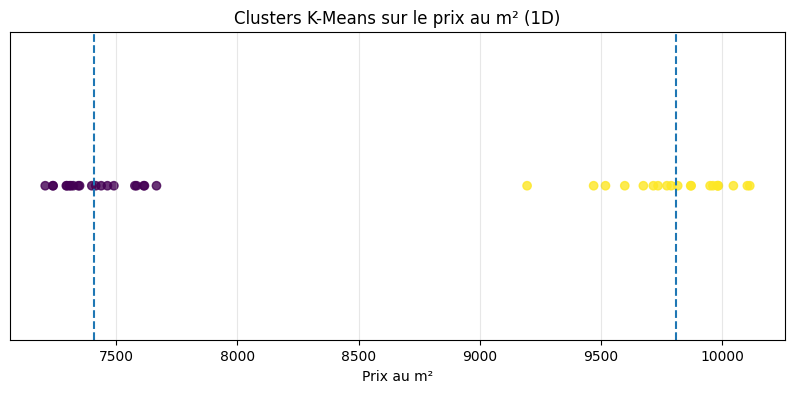

In [ ]:
# Visualisation des clsuters
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# points (prix_m2) sur une ligne y=0
plt.scatter(df_clust["prix_m2"], [0]*len(df_clust), c=df_clust["cluster"], alpha=0.8)

# centres des clusters
for c in kmeans.cluster_centers_.ravel():
    plt.axvline(c, linestyle="--")

plt.title("Clusters K-Means sur le prix au m² (1D)")
plt.xlabel("Prix au m²")
plt.yticks([])
plt.grid(True, alpha=0.3)
plt.show()

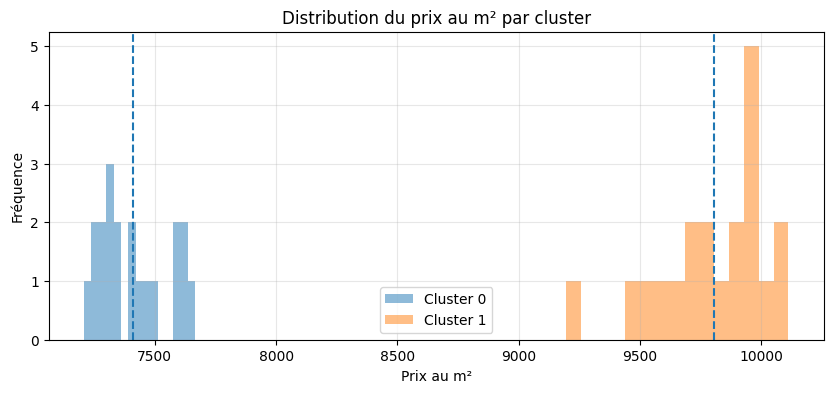

In [ ]:
# Distribution du prix au m2 par cluster
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for cl in sorted(df_clust["cluster"].unique()):
    plt.hist(df_clust.loc[df_clust["cluster"]==cl, "prix_m2"], bins=15, alpha=0.5, label=f"Cluster {cl}")

for c in kmeans.cluster_centers_.ravel():
    plt.axvline(c, linestyle="--")

plt.title("Distribution du prix au m² par cluster")
plt.xlabel("Prix au m²")
plt.ylabel("Fréquence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# On vérifie les données de la prédiction

print("Clusters présents :", df_clust["cluster"].unique())
print("\nNombre de biens par cluster :")
display(df_clust["cluster"].value_counts().sort_index())

print("\nCentroïdes (€/m²) :")
display(pd.Series(kmeans.cluster_centers_.ravel()).sort_values().reset_index(drop=True))

print("\nStatistiques par cluster (prix_m2) :")
display(df_clust.groupby("cluster")["prix_m2"].describe())


Clusters présents : [1 0]

Nombre de biens par cluster :


,count
cluster,
0,20
1,20



Centroïdes (€/m²) :


,0
0,7408.775030
1,9806.924674



Statistiques par cluster (prix_m2) :


,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,20.0,7408.775030,141.329995,7207.21763,7304.332833,7374.091721,7512.112911,7666.071700
1,20.0,9806.924674,232.955000,9194.69779,9705.214437,9842.717300,9979.592847,10113.195822


**1.Lecture des graphes :** les visualisations montrent deux groupes de prix au m² nettement séparés, avec très peu de recouvrement. On observe un cluster “bas” autour de ~7,4 k€/m² et un cluster “haut” autour de ~9,8 k€/m². Les lignes pointillées (centroïdes) confirment cette séparation.

**2.Résultats chiffrés :** K-Means a réparti l’échantillon de façon équilibrée (20 biens par cluster). Les centroïdes sont d’environ 7 408,78 €/m² (cluster 0) et 9 806,92 €/m² (cluster 1). Les statistiques indiquent une dispersion modérée dans chaque cluster, et une distance entre les deux centres suffisamment grande pour justifier une segmentation en deux classes.

**3.Interprétation métier (prudente) :** conformément à l’hypothèse de travail, le cluster au prix/m² le plus élevé est un bon candidat pour représenter les locaux commerciaux/assimilés, tandis que le cluster au prix/m² plus faible correspondrait plutôt aux appartements. Cette interprétation reste à valider (échantillon limité et clustering basé sur une seule variable).

Nous avons obtenu notre prédiction. Nous pouvons changer les labels et remplacer les valeurs à 0 par Local industriel. commercial ou assimilé et les valeurs à +1 par Appartement.

In [ ]:
# ---------------------------------------------------------
# Re-labellisation métier des clusters + affichage résultats
# ---------------------------------------------------------

# Centres des clusters (€/m²)
centres = kmeans.cluster_centers_.ravel()

# Cluster "bas" = prix/m² faible ; cluster "haut" = prix/m² élevé
cluster_bas = int(centres.argmin())
cluster_haut = int(centres.argmax())

mapping = {
    cluster_bas: "Appartement",
    cluster_haut: "Local industriel, commercial ou assimilé"
}

df_result = df_clust.copy()
df_result["type_local_pred"] = df_result["cluster"].map(mapping)

print("Centroïdes (€/m²) :", centres)
print("Mapping utilisé :", mapping)

# On affiche les résultats
display(df_result[["code_postal", "nom_commune", "prix_m2", "cluster", "type_local_pred"]].head(10))

Centroïdes (€/m²) : [7408.77502952 9806.92467429]
Mapping utilisé : {0: 'Appartement', 1: 'Local industriel, commercial ou assimilé'}


,code_postal,nom_commune,prix_m2,cluster,type_local_pred
0,75019,Paris 19e Arrondissement,9871.444128,1,"Local industriel, commercial ou assimilé"
1,75019,Paris 19e Arrondissement,10045.572493,1,"Local industriel, commercial ou assimilé"
2,75019,Paris 19e Arrondissement,9194.697790,1,"Local industriel, commercial ou assimilé"
3,75019,Paris 19e Arrondissement,9469.142168,1,"Local industriel, commercial ou assimilé"
4,75019,Paris 19e Arrondissement,7463.610005,0,Appartement
5,75019,Paris 19e Arrondissement,9982.016919,1,"Local industriel, commercial ou assimilé"
6,75019,Paris 19e Arrondissement,9674.262777,1,"Local industriel, commercial ou assimilé"
7,75019,Paris 19e Arrondissement,7348.917415,0,Appartement
8,75019,Paris 19e Arrondissement,9789.051438,1,"Local industriel, commercial ou assimilé"
9,75019,Paris 19e Arrondissement,7616.420959,0,Appartement


Les labels 0/1 produits par K-Means étant arbitraires, nous les interprétons à partir des centroïdes : le cluster au prix/m² le plus faible est associé aux appartements, et le cluster au prix/m² le plus élevé aux locaux commerciaux/assimilés.

In [ ]:
# ---------------------------------------------------------
# DataFrame final au format commanditaire
# ---------------------------------------------------------

# Copie des données d'origine
df_final = df_a_classer.copy()

# Ajout du label prédit
df_final["type_local"] = df_result["type_local_pred"]

# Ajout du code_type_local cohérent avec le label métier
df_final["code_type_local"] = df_final["type_local"].map({
    "Appartement": 2,
    "Local industriel, commercial ou assimilé": 4
})

# Réorganisation des colonnes dans l'ordre du fichier solution
df_final = df_final[
    [
        "valeur_fonciere",
        "code_postal",
        "nom_commune",
        "code_type_local",
        "type_local",
        "surface_reelle"
    ]
]

# Vérification
display(df_final.head(40))
df_final.info()

,valeur_fonciere,code_postal,nom_commune,code_type_local,type_local,surface_reelle
0,868687.083271,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",88
1,452050.762192,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",45
2,193088.653587,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",21
3,303012.549370,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",32
4,149272.200110,75019,Paris 19e Arrondissement,2,Appartement,20
5,179676.304545,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",18
6,241856.569418,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",25
7,462981.797149,75019,Paris 19e Arrondissement,2,Appartement,63
8,518819.726233,75019,Paris 19e Arrondissement,4,"Local industriel, commercial ou assimilé",53
9,403670.310822,75019,Paris 19e Arrondissement,2,Appartement,53


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   valeur_fonciere  40 non-null     float64
 1   code_postal      40 non-null     int64  
 2   nom_commune      40 non-null     object 
 3   code_type_local  40 non-null     int64  
 4   type_local       40 non-null     object 
 5   surface_reelle   40 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.0+ KB


In [ ]:
# ----------------------------------------------------
# Sauvegardes fichiers de résultat (Milestone 4)
# --------------------------------------------------
from pathlib import Path

# Dossier de sortie
DIR_S4 = PROJECT_ROOT / "data" / "04_step4_clustering"
DIR_S4.mkdir(parents=True, exist_ok=True)

# Export CSV (recommandé)
out_csv = DIR_S4 / "echantillon_a_classer2_kmeans_labels.csv"
df_result.to_csv(out_csv, index=False)

print("Export CSV ->", out_csv)

# Export Parquet (optionnel)
out_parquet = DIR_S4 / "echantillon_a_classer2_kmeans_labels.parquet"

try:
    df_result.to_parquet(out_parquet, index=False)
    print("Export Parquet ->", out_parquet)

except Exception as e:
    print("Parquet non exporté (pyarrow/fastparquet manquant).")
    print("Détail :", e)

Export CSV -> /content/drive/MyDrive/OC_P8_Immobilier/data/04_step4_clustering/echantillon_a_classer2_kmeans_labels.csv
Export Parquet -> /content/drive/MyDrive/OC_P8_Immobilier/data/04_step4_clustering/echantillon_a_classer2_kmeans_labels.parquet


In [ ]:
# ---------------------------------------------------------------------
# Sauvegardes fichiers df_final au format commanditaire (Milestone 4)
# -------------------------------------------------------------------------
csv_final = DIR_S4 / "echantillon_a_classer2_predict.csv"
xlsx_final = DIR_S4 / "echantillon_a_classer2_predict.xlsx"
df_final.to_csv(csv_final, index=False)
df_final.to_excel(xlsx_final, index=False)
print("CSV df_final ->", csv_final)
print("Excel df_final ->", xlsx_final)

CSV df_final -> /content/drive/MyDrive/OC_P8_Immobilier/data/04_step4_clustering/echantillon_a_classer2_predict.csv
Excel df_final -> /content/drive/MyDrive/OC_P8_Immobilier/data/04_step4_clustering/echantillon_a_classer2_predict.xlsx


# Milestone 5 - Analyse et présentation des résultats

# **Mes conclusions sur l’analyse (incluant la classification)**

**1.Tendance marché :** entre 2017 et 2021, les prix au m² à Paris progressent globalement, avec des écarts significatifs selon les arrondissements et selon le type de bien (appartements vs locaux).

**2.Valorisation du portefeuille :** la valorisation estimée au 31/12/2022 indique que la branche corporate (locaux commerciaux/assimilés) ressort comme le segment le plus valorisé du portefeuille, devant le segment particuliers.

**3.Classification des opportunités (K-Means) :** sur l’échantillon à classer, le clustering K-Means appliqué au prix au m² met en évidence 2 groupes nettement séparés (centroïdes ≈ 7 409 €/m² et ≈ 9 807 €/m²). Cela permet de labelliser automatiquement les opportunités :

*   cluster “prix bas” → Appartements (hypothèse la plus plausible),
*   cluster “prix haut” → Locaux industriels/commerciaux/assimilés.

Cette approche réduit la qualification manuelle et accélère le tri des opportunités.

**4.Limites et précautions :**

**a.** Données explicatives limitées : les modèles (prédiction + classification) reposent sur peu de variables (surface, localisation, type, temps, prix/m²). Ils n’intègrent pas des facteurs déterminants (état, étage, prestations, micro-localisation, DPE, contraintes d’exploitation côté corporate).

**b.** Extrapolation / robustesse : la prédiction à fin 2022 extrapole un historique 2017–2021 ; en cas de changement de régime de marché, la fiabilité baisse. Résultats à lire comme des ordres de grandeur.

**c.** Limites spécifiques du clustering : K-Means est une méthode non supervisée : les labels 0/1 sont arbitraires et l’interprétation “appartement vs local” repose sur l’hypothèse “prix/m² plus élevé = local”. Une validation avec un petit échantillon labellisé (terrain) est recommandée.

**d.** Contrôles de cohérence : un check par prix au m² (bornes IQR) permet de repérer des cas atypiques à auditer avant décision.